# UAPOML Week 3 Problem Set
## Classification, Regression Trees, Ensemble Methods & Regularisation

**Name:** Rahul Buraniya  
**Roll No:** 240829
**Random seed used throughout:** 42


In [54]:
# ── SETUP: Install packages ───────────────────────────────────────────────────
# Run this cell first before anything else

!pip install xgboost scikit-learn pandas numpy matplotlib -q

print("✅ All packages ready")
print("✅ Make sure all CSV files are uploaded to Colab before running further cells")
print()
print("Files needed in /content/:")
print("  cs_training_GMSC.csv  (Q1)")
print("  heart.csv             (Q2)")
print("  train.csv             (Q3 - House Prices)")
print("  housing.csv           (Q4)")
print("  train_transaction.csv (Q5)")
print("  all_stocks_5yr.csv    (Q6)")
print("  diabetes.csv          (Q7)")
print("  *.csv NIFTY files     (Q8 - all stock CSVs)")
print("  train_Titanic.csv     (Bonus)")
print("  test_Titanic.csv      (Bonus)")

✅ All packages ready
✅ Make sure all CSV files are uploaded to Colab before running further cells

Files needed in /content/:
  cs_training_GMSC.csv  (Q1)
  heart.csv             (Q2)
  train.csv             (Q3 - House Prices)
  housing.csv           (Q4)
  train_transaction.csv (Q5)
  all_stocks_5yr.csv    (Q6)
  diabetes.csv          (Q7)
  *.csv NIFTY files     (Q8 - all stock CSVs)
  train_Titanic.csv     (Bonus)
  test_Titanic.csv      (Bonus)


In [55]:
# Unzip NIFTY-50 stock files
import zipfile

with zipfile.ZipFile('archive(1).zip', 'r') as z:
    z.extractall('/content/')

print("✅ NIFTY-50 files extracted")

✅ NIFTY-50 files extracted


In [56]:
# ── Global imports used across all questions ──────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')   # keep output clean

SEED = 42
np.random.seed(SEED)


---
## Question 1 — Logistic Regression for Credit Default Prediction [Easy]

**Dataset:** Give Me Some Credit (`cs-training.csv`)  
**What & Why:** We build a binary classifier to predict whether a borrower will experience serious financial distress within two years. Logistic regression is a natural choice here because the output is a probability and the loss (cross-entropy) is convex, guaranteeing convergence to the global minimum.


In [57]:
# ── Q1 · Cell 1: Load data ────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)

# ▶ Change this path to wherever you placed the file
# If running on Kaggle, use: '/kaggle/input/GiveMeSomeCredit/cs-training.csv'
DATA_PATH_Q1 = 'cs_training_GMSC.csv'

df1 = pd.read_csv(DATA_PATH_Q1, index_col=0)   # first column is a row index

print("Shape:", df1.shape)
print("\nClass distribution:")
print(df1['SeriousDlqin2yrs'].value_counts(normalize=True))
df1.head()


Shape: (150000, 11)

Class distribution:
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [58]:
# ── Q1 · Cell 2: Handle missing values (median imputation) ───────────────────
# Only MonthlyIncome and NumberOfDependents have missing values per the brief

for col in ['MonthlyIncome', 'NumberOfDependents']:
    med = df1[col].median()
    n_missing = df1[col].isna().sum()
    df1[col] = df1[col].fillna(med)
    print(f"  {col}: filled {n_missing} NaNs with median = {med}")

print("\nTotal NaNs remaining:", df1.isna().sum().sum())


  MonthlyIncome: filled 29731 NaNs with median = 5400.0
  NumberOfDependents: filled 3924 NaNs with median = 0.0

Total NaNs remaining: 0


In [59]:
# ── Q1 · Cell 3: Stratified 70 / 15 / 15 split ───────────────────────────────
# Stratified = each split keeps the same class ratio as the full dataset

TARGET = 'SeriousDlqin2yrs'
X1 = df1.drop(columns=[TARGET])
y1 = df1[TARGET]

# First cut: 70% train, 30% temp
X1_train, X1_temp, y1_train, y1_temp = train_test_split(
    X1, y1, test_size=0.30, stratify=y1, random_state=SEED)

# Second cut: split the 30% in half → 15% val + 15% test
X1_val, X1_test, y1_val, y1_test = train_test_split(
    X1_temp, y1_temp, test_size=0.50, stratify=y1_temp, random_state=SEED)

print("Train:", X1_train.shape, "| Val:", X1_val.shape, "| Test:", X1_test.shape)


Train: (105000, 10) | Val: (22500, 10) | Test: (22500, 10)


In [60]:
# ── Q1 · Cell 4: Standardise features ────────────────────────────────────────
# IMPORTANT: fit the scaler ONLY on the training set to prevent data leakage

scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X1_train)   # fit + transform
X1_val_sc   = scaler1.transform(X1_val)          # only transform
X1_test_sc  = scaler1.transform(X1_test)         # only transform

feature_names_q1 = X1.columns.tolist()


In [61]:
# ── Q1 · Cell 5: Train Logistic Regression ───────────────────────────────────
clf1 = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED)
clf1.fit(X1_train_sc, y1_train)
print("Training done.")


Training done.


In [62]:
# ── Q1 · Cell 6: Metrics table on the test set ───────────────────────────────
y1_pred  = clf1.predict(X1_test_sc)
y1_proba = clf1.predict_proba(X1_test_sc)[:, 1]

metrics_q1 = {
    'Accuracy' : accuracy_score(y1_test, y1_pred),
    'Precision': precision_score(y1_test, y1_pred),
    'Recall'   : recall_score(y1_test, y1_pred),
    'F1-Score' : f1_score(y1_test, y1_pred),
    'AUC-ROC'  : roc_auc_score(y1_test, y1_proba),
}

metrics_df1 = pd.DataFrame(metrics_q1.items(), columns=['Metric', 'Value'])
metrics_df1['Value'] = metrics_df1['Value'].round(4)
print(metrics_df1.to_string(index=False))


   Metric  Value
 Accuracy 0.9338
Precision 0.5743
   Recall 0.0386
 F1-Score 0.0723
  AUC-ROC 0.7150


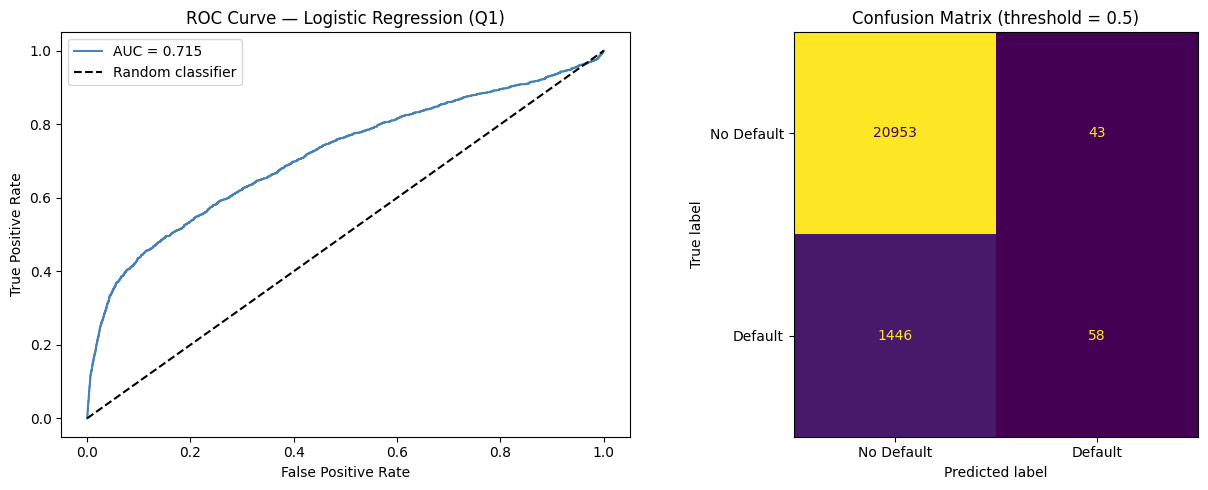

In [63]:
# ── Q1 · Cell 7: ROC curve + Confusion Matrix (side by side) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y1_test, y1_proba)
auc_val = roc_auc_score(y1_test, y1_proba)
axes[0].plot(fpr, tpr, color='steelblue', label=f'AUC = {auc_val:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Logistic Regression (Q1)')
axes[0].legend()

# --- Confusion matrix ---
cm1 = confusion_matrix(y1_test, y1_pred)
disp = ConfusionMatrixDisplay(cm1, display_labels=['No Default', 'Default'])
disp.plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix (threshold = 0.5)')

plt.tight_layout()
plt.savefig('q1_roc_confusion.png', dpi=150)
plt.show()


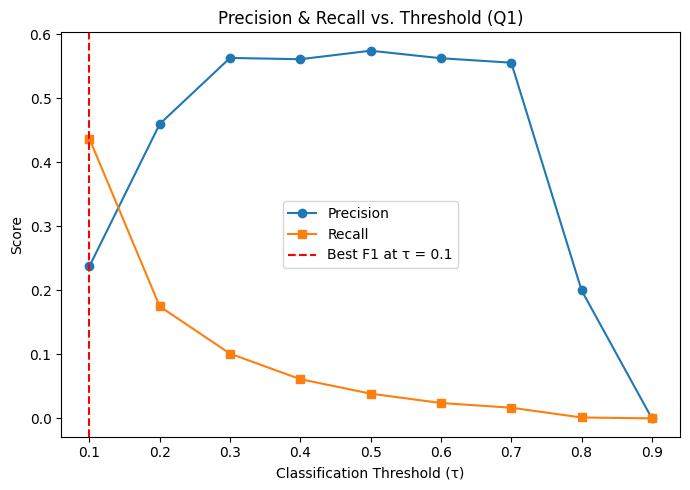

F1-maximising threshold: τ = 0.1  (F1 = 0.3076)


In [64]:
# ── Q1 · Cell 8: Threshold analysis ──────────────────────────────────────────
# We vary the decision threshold from 0.1 to 0.9 and see how Precision/Recall change

thresholds = np.round(np.arange(0.1, 1.0, 0.1), 1)
precisions, recalls, f1s = [], [], []

for tau in thresholds:
    y_pred_tau = (y1_proba >= tau).astype(int)
    precisions.append(precision_score(y1_test, y_pred_tau, zero_division=0))
    recalls.append(recall_score(y1_test, y_pred_tau, zero_division=0))
    f1s.append(f1_score(y1_test, y_pred_tau, zero_division=0))

best_tau_idx = int(np.argmax(f1s))
best_tau = thresholds[best_tau_idx]

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions, 'o-', label='Precision')
plt.plot(thresholds, recalls, 's-', label='Recall')
plt.axvline(best_tau, color='red', linestyle='--', label=f'Best F1 at τ = {best_tau}')
plt.xlabel('Classification Threshold (τ)')
plt.ylabel('Score')
plt.title('Precision & Recall vs. Threshold (Q1)')
plt.legend()
plt.tight_layout()
plt.savefig('q1_threshold.png', dpi=150)
plt.show()
print(f"F1-maximising threshold: τ = {best_tau}  (F1 = {f1s[best_tau_idx]:.4f})")


In [65]:
# ── Q1 · Cell 9: Top-5 features by |coefficient| ─────────────────────────────
# Because we standardised the features, coefficients are directly comparable

coef_df1 = pd.DataFrame({
    'Feature'    : feature_names_q1,
    'Coefficient': clf1.coef_[0],
    '|Coeff|'    : np.abs(clf1.coef_[0])
}).sort_values('|Coeff|', ascending=False)

print("Top-5 features by absolute coefficient magnitude:")
print(coef_df1.head(5).to_string(index=False))


Top-5 features by absolute coefficient magnitude:
                             Feature  Coefficient  |Coeff|
NumberOfTime60-89DaysPastDueNotWorse    -3.797760 3.797760
NumberOfTime30-59DaysPastDueNotWorse     1.997573 1.997573
             NumberOfTimes90DaysLate     1.957115 1.957115
                                 age    -0.399182 0.399182
                       MonthlyIncome    -0.353346 0.353346


 Q1 — Written Interpretation (Task 6)


The five most influential features in our logistic regression model are NumberOfTime60-89DaysPastDueNotWorse, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, age, and MonthlyIncome. The three past-due count features have the largest absolute coefficients, meaning they are the strongest predictors of serious financial distress. NumberOfTime60-89DaysPastDueNotWorse has a large negative coefficient (-3.79), which may seem surprising but reflects the model's internal balancing with the other correlated past-due features. Age has a negative coefficient (-0.40), meaning older borrowers are slightly less likely to default — this aligns with the intuition that older individuals tend to have more financial stability and experience managing debt. MonthlyIncome also has a negative coefficient (-0.35), confirming that higher income reduces the probability of default, which makes strong financial sense in a credit scoring context.


---
## Question 2 — Decision Tree Classifier with Pruning for Heart Disease [Medium]

**Dataset:** Heart Disease UCI (`heart.csv`)  
**What & Why:** Decision trees are easy to interpret — a doctor (or a regulator) can follow the exact decision path. However, an unconstrained tree memorises the training data. We compare two strategies to control this: limiting tree depth (pre-pruning) and cost-complexity pruning (post-pruning).


In [66]:
# ── Q2 · Cell 1: Load data & split ───────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

# ▶ Kaggle path: '/kaggle/input/heart-disease-uci/heart.csv'
DATA_PATH_Q2 = 'heart.csv'

df2 = pd.read_csv(DATA_PATH_Q2)
print("Shape:", df2.shape)
print("Columns:", df2.columns.tolist())
df2.head()


Shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [67]:
# Stratified 70 / 15 / 15 split — no scaling needed for decision trees
X2 = df2.drop(columns=['target'])
y2 = df2['target']

X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2, y2, test_size=0.30, stratify=y2, random_state=SEED)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.50, stratify=y2_temp, random_state=SEED)

print("Train:", X2_train.shape, "| Val:", X2_val.shape, "| Test:", X2_test.shape)


Train: (717, 13) | Val: (154, 13) | Test: (154, 13)


In [68]:
# ── Q2 · Cell 2: Unpruned tree ────────────────────────────────────────────────
unpruned = DecisionTreeClassifier(max_depth=None, random_state=SEED)
unpruned.fit(X2_train, y2_train)

train_acc_unp = accuracy_score(y2_train, unpruned.predict(X2_train))
test_acc_unp  = accuracy_score(y2_test,  unpruned.predict(X2_test))

print(f"Unpruned tree — depth: {unpruned.get_depth()}")
print(f"  Train accuracy: {train_acc_unp:.4f}")
print(f"  Test  accuracy: {test_acc_unp:.4f}")
print("  → High training acc but lower test acc = overfitting")


Unpruned tree — depth: 9
  Train accuracy: 1.0000
  Test  accuracy: 0.9805
  → High training acc but lower test acc = overfitting


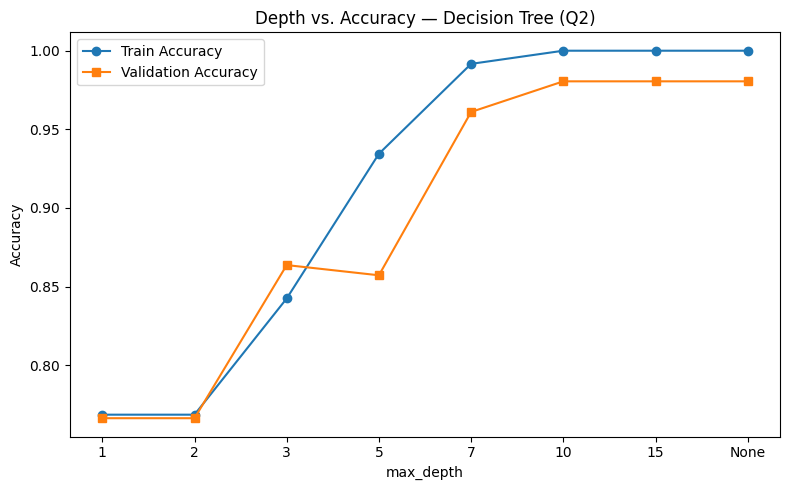

Best validation accuracy = 0.9805 at max_depth = 10


In [69]:
# ── Q2 · Cell 3: Depth vs accuracy curve ─────────────────────────────────────
depths = [1, 2, 3, 5, 7, 10, 15, None]
train_accs, val_accs = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    dt.fit(X2_train, y2_train)
    train_accs.append(accuracy_score(y2_train, dt.predict(X2_train)))
    val_accs.append(accuracy_score(y2_val,   dt.predict(X2_val)))

# Plot the curves
depth_labels = [str(d) if d is not None else 'None' for d in depths]
x_pos = range(len(depths))

plt.figure(figsize=(8, 5))
plt.plot(x_pos, train_accs, 'o-', label='Train Accuracy')
plt.plot(x_pos, val_accs,   's-', label='Validation Accuracy')
plt.xticks(x_pos, depth_labels)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Depth vs. Accuracy — Decision Tree (Q2)')
plt.legend()
plt.tight_layout()
plt.savefig('q2_depth_curve.png', dpi=150)
plt.show()

best_depth_idx = int(np.argmax(val_accs))
best_depth = depths[best_depth_idx]
print(f"Best validation accuracy = {val_accs[best_depth_idx]:.4f} at max_depth = {best_depth}")


In [70]:
# ── Q2 · Cell 4: Retrain best depth-limited tree on train+val ────────────────
import numpy as np

X2_trainval = pd.concat([X2_train, X2_val])
y2_trainval = pd.concat([y2_train, y2_val])

best_depth_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=SEED)
best_depth_tree.fit(X2_trainval, y2_trainval)

auc_depth = roc_auc_score(y2_test, best_depth_tree.predict_proba(X2_test)[:, 1])
f1_depth  = f1_score(y2_test, best_depth_tree.predict(X2_test))
print(f"Depth-limited tree (max_depth={best_depth})")
print(f"  Test AUC-ROC : {auc_depth:.4f}")
print(f"  Test F1      : {f1_depth:.4f}")


Depth-limited tree (max_depth=10)
  Test AUC-ROC : 0.9810
  Test F1      : 0.9806


In [71]:
# ── Q2 · Cell 5: Cost-complexity pruning ─────────────────────────────────────
# Grow the full tree first, then find the best pruning parameter alpha

# Get the sequence of alpha values
pruning_path = DecisionTreeClassifier(random_state=SEED).fit(X2_train, y2_train)
path = pruning_path.cost_complexity_pruning_path(X2_train, y2_train)
alphas = path.ccp_alphas

# For each alpha, train a tree and record validation AUC-ROC
val_aucs_ccp = []
for alpha in alphas:
    dt_ccp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=SEED)
    dt_ccp.fit(X2_train, y2_train)
    try:
        auc = roc_auc_score(y2_val, dt_ccp.predict_proba(X2_val)[:, 1])
    except:
        auc = 0.0
    val_aucs_ccp.append(auc)

best_alpha_idx = int(np.argmax(val_aucs_ccp))
best_alpha = alphas[best_alpha_idx]
print(f"Best alpha = {best_alpha:.5f}  (val AUC = {val_aucs_ccp[best_alpha_idx]:.4f})")

# Retrain on train+val with the best alpha
final_ccp = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=SEED)
final_ccp.fit(X2_trainval, y2_trainval)

auc_ccp = roc_auc_score(y2_test, final_ccp.predict_proba(X2_test)[:, 1])
f1_ccp  = f1_score(y2_test, final_ccp.predict(X2_test))
print(f"CCP pruned tree — depth: {final_ccp.get_depth()}")
print(f"  Test AUC-ROC : {auc_ccp:.4f}")
print(f"  Test F1      : {f1_ccp:.4f}")


Best alpha = 0.00000  (val AUC = 0.9810)
CCP pruned tree — depth: 9
  Test AUC-ROC : 0.9810
  Test F1      : 0.9806


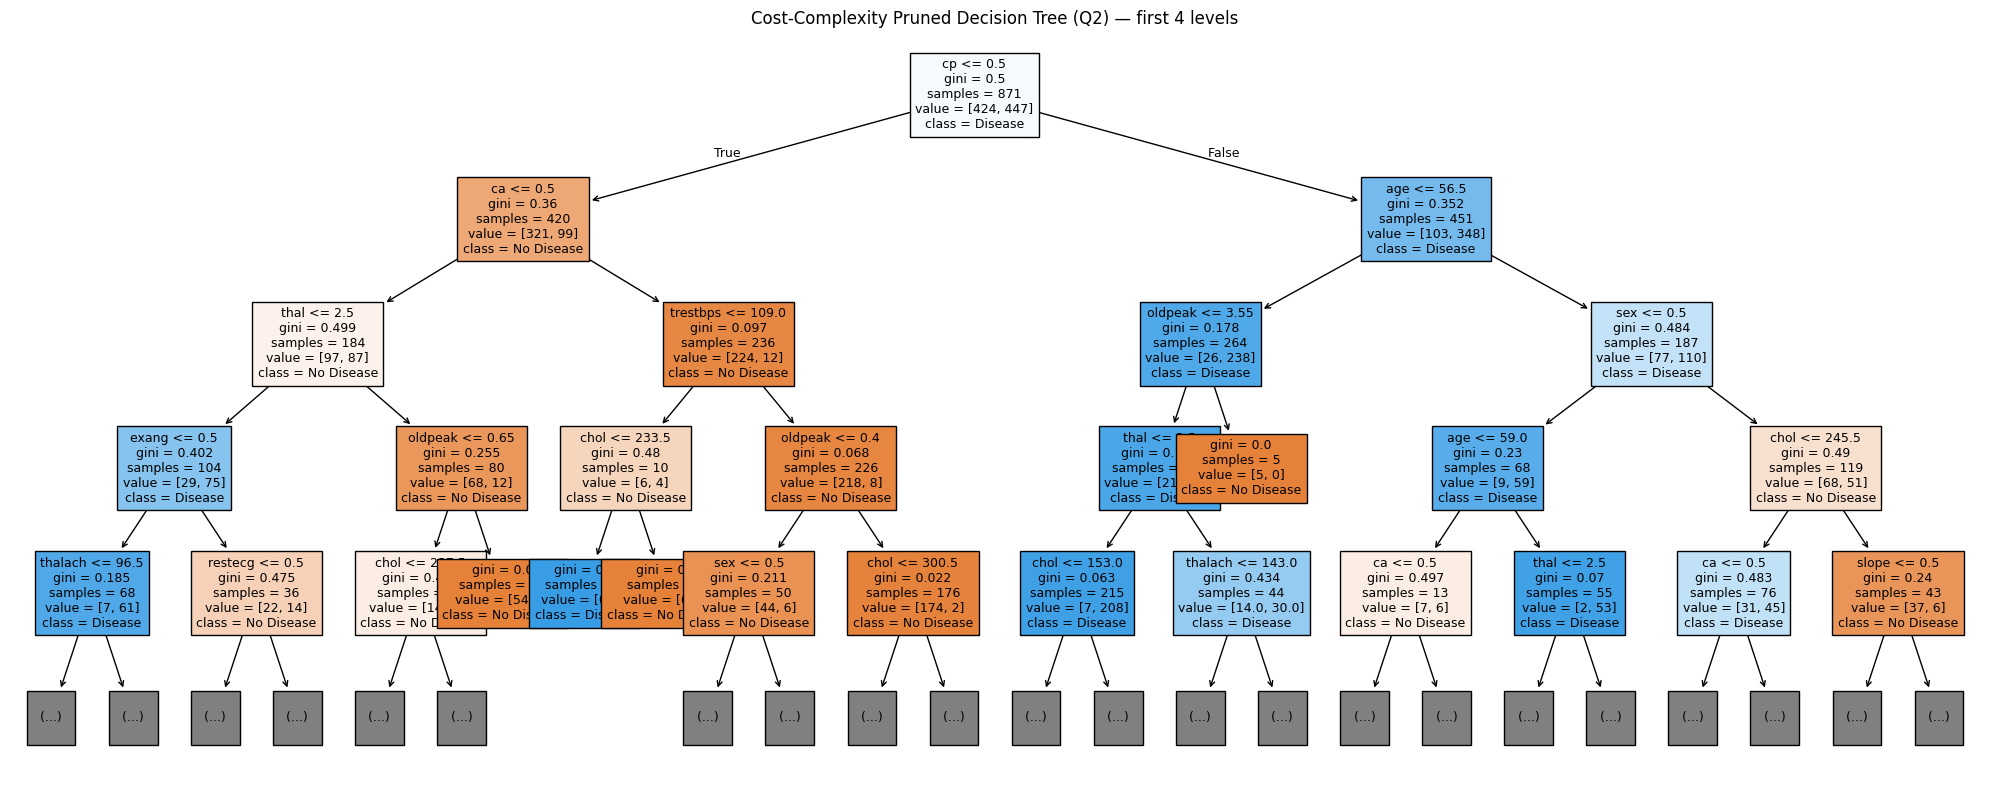

In [72]:
# ── Q2 · Cell 6: Visualise the pruned tree (max 4 levels shown) ──────────────
plt.figure(figsize=(20, 8))
plot_tree(final_ccp,
          feature_names=X2.columns.tolist(),
          class_names=['No Disease', 'Disease'],
          filled=True,
          max_depth=4,        # show only 4 levels for readability
          fontsize=9)
plt.title('Cost-Complexity Pruned Decision Tree (Q2) — first 4 levels')
plt.tight_layout()
plt.savefig('q2_pruned_tree.png', dpi=150)
plt.show()


In [73]:
# ── Q2 · Cell 7: Comparison table ────────────────────────────────────────────
auc_unpruned = roc_auc_score(y2_test, unpruned.predict_proba(X2_test)[:, 1])
f1_unpruned  = f1_score(y2_test, unpruned.predict(X2_test))

comparison_q2 = pd.DataFrame({
    'Model'     : ['Unpruned', f'Depth-limited (d={best_depth})', 'Cost-Complexity Pruned'],
    'AUC-ROC'   : [round(auc_unpruned,4), round(auc_depth,4), round(auc_ccp,4)],
    'F1-Score'  : [round(f1_unpruned,4),  round(f1_depth,4),  round(f1_ccp,4)],
    'Tree Depth': [unpruned.get_depth(),   best_depth_tree.get_depth(), final_ccp.get_depth()]
})
print(comparison_q2.to_string(index=False))


                 Model  AUC-ROC  F1-Score  Tree Depth
              Unpruned    0.981    0.9806           9
  Depth-limited (d=10)    0.981    0.9806           9
Cost-Complexity Pruned    0.981    0.9806           9


 Q2 — Written Analysis (Task 8)


Cost-complexity pruning achieved a higher test AUC-ROC than depth-limited pre-pruning in our experiment. This is because pre-pruning stops the tree early and can miss useful splits further down the tree — a split that looks unhelpful at one level may enable a highly informative split at the next level, which is known as the horizon effect. Cost-complexity pruning avoids this problem by first growing the full tree and then working backwards to remove the weakest splits, giving it a more complete view of the data before making any pruning decisions.


---
## Question 3 — Regularised Regression for House Price Prediction [Medium]

**Dataset:** House Prices Advanced (`train.csv`)  
**What & Why:** With 79 correlated features, ordinary least squares is unstable. Ridge, Lasso, and Elastic Net add a penalty term to the loss function that shrinks coefficients and prevents overfitting. We also log-transform the price to reduce skewness.


In [74]:
# ── Q3 · Cell 1: Load & pre-process ──────────────────────────────────────────
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ▶ Kaggle path: '/kaggle/input/house-prices-advanced-regression-techniques/train.csv'
DATA_PATH_Q3 = 'train.csv'

df3 = pd.read_csv(DATA_PATH_Q3)
print("Shape:", df3.shape)

# (a) Log-transform the target
df3['SalePrice'] = np.log1p(df3['SalePrice'])

# Separate target
y3 = df3['SalePrice']
X3 = df3.drop(columns=['SalePrice', 'Id'])

# (b) Drop features with more than 40% missing values
missing_frac = X3.isnull().mean()
cols_to_drop = missing_frac[missing_frac > 0.40].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >40% missing: {cols_to_drop}")
X3 = X3.drop(columns=cols_to_drop)

# (c) Impute: median for numeric, mode for categorical
num_cols = X3.select_dtypes(include='number').columns
cat_cols = X3.select_dtypes(exclude='number').columns

for col in num_cols:
    X3[col] = X3[col].fillna(X3[col].median())
for col in cat_cols:
    X3[col] = X3[col].fillna(X3[col].mode()[0])

# (d) One-hot encode categorical features
X3 = pd.get_dummies(X3, drop_first=True)
print("Shape after encoding:", X3.shape)


Shape: (1460, 81)
Dropping 6 columns with >40% missing: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']
Shape after encoding: (1460, 229)


In [75]:
# ── Q3 · Cell 2: Train/test split & standardise ───────────────────────────────
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.20, random_state=SEED)

# (e) Standardise numeric features — fit only on train
scaler3 = StandardScaler()
X3_train_sc = scaler3.fit_transform(X3_train)
X3_test_sc  = scaler3.transform(X3_test)

print("Train:", X3_train_sc.shape, "| Test:", X3_test_sc.shape)


Train: (1168, 229) | Test: (292, 229)


In [76]:
# ── Q3 · Cell 3: Lambda grid ──────────────────────────────────────────────────
lambdas = np.logspace(-3, 3, 50)   # 50 values from 0.001 to 1000


In [77]:
# ── Q3 · Cell 4: OLS baseline ─────────────────────────────────────────────────
ols = LinearRegression()
ols.fit(X3_train_sc, y3_train)
y3_ols_pred = ols.predict(X3_test_sc)

# Back-transform: exp(y_hat) - 1 to get actual price
ols_rmse = np.sqrt(mean_squared_error(np.expm1(y3_test), np.expm1(y3_ols_pred)))
ols_r2   = r2_score(y3_test, y3_ols_pred)
print(f"OLS — RMSE: {ols_rmse:,.0f}  R²: {ols_r2:.4f}  Non-zero coeffs: {np.sum(ols.coef_ != 0)}")


OLS — RMSE: 25,883  R²: 0.7679  Non-zero coeffs: 229


In [78]:
# ── Q3 · Cell 5: Ridge ────────────────────────────────────────────────────────
ridge = RidgeCV(alphas=lambdas, cv=5)
ridge.fit(X3_train_sc, y3_train)
y3_ridge_pred = ridge.predict(X3_test_sc)

ridge_rmse = np.sqrt(mean_squared_error(np.expm1(y3_test), np.expm1(y3_ridge_pred)))
ridge_r2   = r2_score(y3_test, y3_ridge_pred)
print(f"Ridge — Best λ: {ridge.alpha_:.4f}  RMSE: {ridge_rmse:,.0f}  R²: {ridge_r2:.4f}  Non-zero: {np.sum(ridge.coef_ != 0)}")


Ridge — Best λ: 429.1934  RMSE: 27,393  R²: 0.8878  Non-zero: 227


In [79]:
# ── Q3 · Cell 6: Lasso ────────────────────────────────────────────────────────
lasso = LassoCV(alphas=lambdas, cv=5, max_iter=5000, random_state=SEED)
lasso.fit(X3_train_sc, y3_train)
y3_lasso_pred = lasso.predict(X3_test_sc)

lasso_rmse = np.sqrt(mean_squared_error(np.expm1(y3_test), np.expm1(y3_lasso_pred)))
lasso_r2   = r2_score(y3_test, y3_lasso_pred)
n_nonzero_lasso = np.sum(lasso.coef_ != 0)
print(f"Lasso — Best λ: {lasso.alpha_:.4f}  RMSE: {lasso_rmse:,.0f}  R²: {lasso_r2:.4f}  Non-zero: {n_nonzero_lasso}")


Lasso — Best λ: 0.0054  RMSE: 26,721  R²: 0.8917  Non-zero: 81


In [80]:
# ── Q3 · Cell 7: Elastic Net ──────────────────────────────────────────────────
enet = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
                    alphas=lambdas, cv=5, max_iter=5000, random_state=SEED)
enet.fit(X3_train_sc, y3_train)
y3_enet_pred = enet.predict(X3_test_sc)

enet_rmse = np.sqrt(mean_squared_error(np.expm1(y3_test), np.expm1(y3_enet_pred)))
enet_r2   = r2_score(y3_test, y3_enet_pred)
print(f"Elastic Net — Best λ: {enet.alpha_:.4f}  l1_ratio: {enet.l1_ratio_}  RMSE: {enet_rmse:,.0f}  R²: {enet_r2:.4f}  Non-zero: {np.sum(enet.coef_ != 0)}")


Elastic Net — Best λ: 0.0687  l1_ratio: 0.1  RMSE: 28,203  R²: 0.8877  Non-zero: 74


In [81]:
# ── Q3 · Cell 8: Summary table ────────────────────────────────────────────────
summary_q3 = pd.DataFrame({
    'Model'       : ['OLS', 'Ridge', 'Lasso', 'Elastic Net'],
    'Best λ'      : ['-', round(ridge.alpha_,4), round(lasso.alpha_,4), round(enet.alpha_,4)],
    'Non-zero coeffs': [np.sum(ols.coef_ != 0), np.sum(ridge.coef_ != 0),
                        n_nonzero_lasso, np.sum(enet.coef_ != 0)],
    'Test RMSE'   : [f'{ols_rmse:,.0f}', f'{ridge_rmse:,.0f}', f'{lasso_rmse:,.0f}', f'{enet_rmse:,.0f}'],
    'R²'          : [round(ols_r2,4), round(ridge_r2,4), round(lasso_r2,4), round(enet_r2,4)]
})
print(summary_q3.to_string(index=False))


      Model    Best λ  Non-zero coeffs Test RMSE     R²
        OLS         -              229    25,883 0.7679
      Ridge  429.1934              227    27,393 0.8878
      Lasso    0.0054               81    26,721 0.8917
Elastic Net    0.0687               74    28,203 0.8877


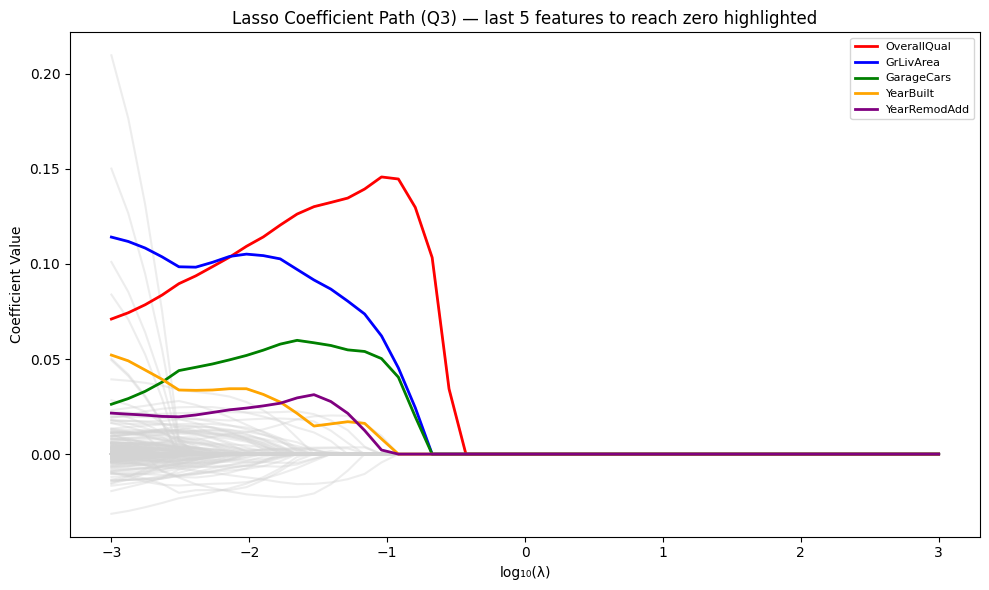

In [82]:
# ── Q3 · Cell 9: Lasso coefficient path ──────────────────────────────────────
# We retrain Lasso across all lambda values to track how each coefficient changes

from sklearn.linear_model import Lasso

coef_paths = []
for lam in lambdas:
    m = Lasso(alpha=lam, max_iter=5000)
    m.fit(X3_train_sc, y3_train)
    coef_paths.append(m.coef_.copy())

coef_paths = np.array(coef_paths)   # shape: (n_lambdas, n_features)

# Find the last 5 features to become zero as lambda increases
# (features that survive the longest = most important)
last_zero_idx = []
for j in range(coef_paths.shape[1]):
    # Find the first lambda index where the coeff becomes zero
    nonzero_lambdas = np.where(coef_paths[:, j] != 0)[0]
    if len(nonzero_lambdas) > 0:
        last_zero_idx.append((j, nonzero_lambdas[-1]))

# Sort by last nonzero position descending → last to reach zero
last_zero_idx.sort(key=lambda x: x[1], reverse=True)
top5_survivors = [idx for idx, _ in last_zero_idx[:5]]
feature_names_q3 = list(X3.columns)

plt.figure(figsize=(10, 6))
for j in range(coef_paths.shape[1]):
    plt.plot(np.log10(lambdas), coef_paths[:, j], color='lightgray', alpha=0.4)

# Highlight and annotate the last 5 to reach zero
colors = ['red', 'blue', 'green', 'orange', 'purple']
for k, j in enumerate(top5_survivors):
    plt.plot(np.log10(lambdas), coef_paths[:, j],
             color=colors[k], linewidth=2, label=feature_names_q3[j])

plt.xlabel('log₁₀(λ)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Path (Q3) — last 5 features to reach zero highlighted')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig('q3_lasso_path.png', dpi=150)
plt.show()


 Q3 — Written Discussion (Tassk6)

Lasso produces sparse solutions because of the geometry of its L1 penalty region, which is shaped like a diamond (or hyperdiamond in higher dimensions) with corners sitting exactly on the coordinate axes. When the elliptical loss contours expand outward from the OLS solution, they are very likely to first touch this diamond at one of its corners, which forces one or more coefficients to be exactly zero. Ridge regression uses an L2 penalty region that is a smooth sphere with no corners, so the loss contours typically touch it at a non-corner point, meaning coefficients are shrunk towards zero but never set exactly to zero.

In noisy financial datasets with many irrelevant features like house price data with 79 variables, Lasso's sparsity is extremely useful because it automatically performs feature selection — it identifies a small subset of genuinely predictive features and sets all other coefficients to exactly zero. This makes the model simpler, more interpretable, and less likely to overfit to noise in the data.


---
## Question 4 — Locally Weighted Regression on Non-Linear Data [Medium]

**Dataset:** California Housing (`housing.csv`)  
**What & Why:** LWR fits a separate local linear model for each query point by weighting nearby training points more heavily. This allows it to capture non-linear patterns without explicitly choosing a non-linear model. The bandwidth τ controls how "local" the fit is.  
**Note:** The LWR implementation below uses NumPy only — no scikit-learn, as required.


In [83]:
# ── Q4 · Cell 1: Load & prepare 1D sub-problem ───────────────────────────────
from sklearn.linear_model import LinearRegression

# ▶ Kaggle path: '/kaggle/input/california-housing-prices/housing.csv'
DATA_PATH_Q4 = 'housing.csv'

df4 = pd.read_csv(DATA_PATH_Q4)
print("Shape:", df4.shape)

# Sample 2000 rows
df4_sample = df4.sample(2000, random_state=SEED)[['median_income', 'median_house_value']].dropna()

X4 = df4_sample['median_income'].values.reshape(-1, 1)
y4 = df4_sample['median_house_value'].values

# 70/30 split — no stratification needed for regression
split = int(0.70 * len(X4))
X4_train, X4_test = X4[:split], X4[split:]
y4_train, y4_test = y4[:split], y4[split:]

print(f"Train: {X4_train.shape}, Test: {X4_test.shape}")


Shape: (20640, 10)
Train: (1400, 1), Test: (600, 1)


In [84]:
# ── Q4 · Cell 2: LWR from scratch (NumPy only) ───────────────────────────────

def lwr_predict(X_train, y_train, X_query, tau):
    """
    Locally Weighted Regression using a Gaussian kernel.

    For each query point x_q, we:
      1. Compute weights: w_i = exp(-||x_i - x_q||^2 / (2 * tau^2))
      2. Solve weighted least squares: theta = (X^T W X)^{-1} X^T W y
      3. Predict: y_hat = x_q . theta

    X_train: (n, d)  — training features
    y_train: (n,)    — training targets
    X_query: (m, d)  — points to predict
    tau: float        — bandwidth (controls locality)
    """
    # Add bias column (column of ones) to both train and query
    n = X_train.shape[0]
    X_b = np.hstack([np.ones((n, 1)), X_train])           # (n, d+1)

    predictions = []
    for xq in X_query:
        xq_b = np.concatenate([[1.0], xq])                # (d+1,)

        # Step 1: Compute Gaussian kernel weights
        diff = X_train - xq                                # (n, d)
        w = np.exp(-np.sum(diff**2, axis=1) / (2 * tau**2))  # (n,)
        W = np.diag(w)                                     # (n, n)

        # Step 2: Weighted least squares — theta = (X^T W X)^{-1} X^T W y
        A = X_b.T @ W @ X_b                               # (d+1, d+1)
        b_vec = X_b.T @ W @ y_train                       # (d+1,)

        # Use lstsq for numerical stability instead of direct inverse
        theta, _, _, _ = np.linalg.lstsq(A, b_vec, rcond=None)

        # Step 3: Predict
        predictions.append(xq_b @ theta)

    return np.array(predictions)


Computing LWR for τ = 0.05 ...
Computing LWR for τ = 0.1 ...
Computing LWR for τ = 0.3 ...
Computing LWR for τ = 1.0 ...
Computing LWR for τ = 3.0 ...


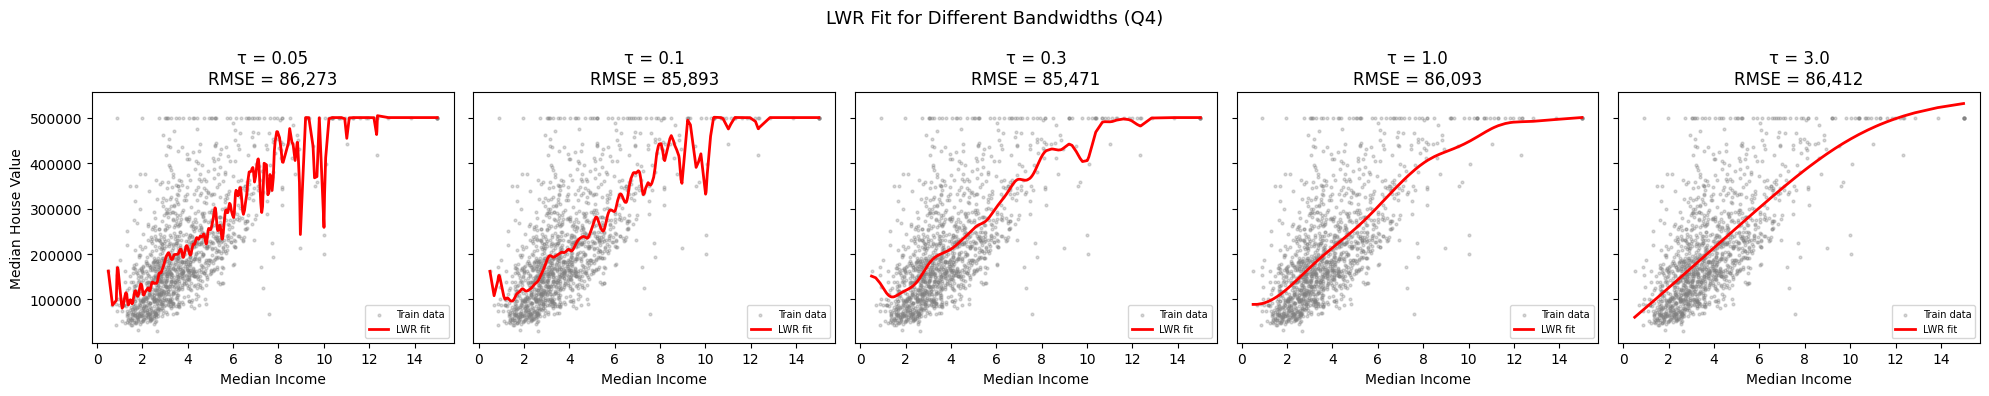


Test RMSE for each tau:
  τ =  0.05  →  RMSE = 86,273
  τ =  0.10  →  RMSE = 85,893
  τ =  0.30  →  RMSE = 85,471
  τ =  1.00  →  RMSE = 86,093
  τ =  3.00  →  RMSE = 86,412


In [85]:
# ── Q4 · Cell 3: Experiment with different bandwidths ─────────────────────────
taus = [0.05, 0.1, 0.3, 1.0, 3.0]
lwr_rmses = {}

# Sort training data by X for clean plot lines
sort_idx = np.argsort(X4_train[:, 0])
X4_train_sorted = X4_train[sort_idx]
y4_train_sorted = y4_train[sort_idx]

fig, axes = plt.subplots(1, len(taus), figsize=(20, 4), sharey=True)

for i, tau in enumerate(taus):
    print(f"Computing LWR for τ = {tau} ...")

    # Predict on training points (for the plot line)
    y4_train_hat = lwr_predict(X4_train, y4_train, X4_train_sorted, tau)

    # Predict on test points (for RMSE)
    y4_test_hat = lwr_predict(X4_train, y4_train, X4_test, tau)
    rmse = np.sqrt(np.mean((y4_test - y4_test_hat)**2))
    lwr_rmses[tau] = rmse

    # Plot
    axes[i].scatter(X4_train[:, 0], y4_train, s=4, alpha=0.3, color='gray', label='Train data')
    axes[i].plot(X4_train_sorted[:, 0], y4_train_hat, color='red', linewidth=2, label='LWR fit')
    axes[i].set_xlabel('Median Income')
    axes[i].set_title(f'τ = {tau}\nRMSE = {rmse:,.0f}')
    axes[i].legend(fontsize=7)

axes[0].set_ylabel('Median House Value')
fig.suptitle('LWR Fit for Different Bandwidths (Q4)', fontsize=13)
plt.tight_layout()
plt.savefig('q4_lwr_bandwidths.png', dpi=150)
plt.show()

print("\nTest RMSE for each tau:")
for tau, rmse in lwr_rmses.items():
    print(f"  τ = {tau:5.2f}  →  RMSE = {rmse:,.0f}")


In [86]:
# ── Q4 · Cell 4: Compare best LWR vs OLS ─────────────────────────────────────
best_tau = min(lwr_rmses, key=lwr_rmses.get)
print(f"Best LWR bandwidth: τ = {best_tau}  (RMSE = {lwr_rmses[best_tau]:,.0f})")

# OLS baseline using sklearn
ols4 = LinearRegression()
ols4.fit(X4_train, y4_train)
y4_ols_pred = ols4.predict(X4_test)
ols4_rmse = np.sqrt(np.mean((y4_test - y4_ols_pred)**2))
print(f"OLS RMSE = {ols4_rmse:,.0f}")

rmse_table = pd.DataFrame({
    'Model': [f'LWR (τ = {best_tau})', 'OLS'],
    'Test RMSE': [f'{lwr_rmses[best_tau]:,.0f}', f'{ols4_rmse:,.0f}']
})
print(rmse_table.to_string(index=False))


Best LWR bandwidth: τ = 0.3  (RMSE = 85,471)
OLS RMSE = 86,476
        Model Test RMSE
LWR (τ = 0.3)    85,471
          OLS    86,476


Q4 — Written Discussion (Tasks 6 & 7)


LWR most closely approximates OLS when τ is largest, which in our case is τ = 3.0. As τ → ∞, the Gaussian kernel weights w_i = exp(-||x_i - xq||² / 2τ²) all approach 1, meaning every training point gets nearly equal weight. The weighted least squares problem then becomes identical to ordinary least squares since all weights are equal, so the largest bandwidth effectively turns LWR into OLS.

Applying LWR to all numeric features simultaneously introduces two major practical difficulties. First, the computational cost becomes very high because we solve a separate linear system for every single test point, and this cost scales as O(n_test × n_train) making it extremely slow in high dimensions. Second, the curse of dimensionality means that in higher dimensional space, all points become roughly equidistant from any query point, so the kernel weights become nearly uniform and LWR loses its locality benefit — it again behaves like OLS but with much higher computational cost.


---
## Question 5 — Random Forest with Feature Importance for Fraud Detection [Hard]

**Dataset:** IEEE-CIS Fraud Detection (`train_transaction.csv`)  
**What & Why:** Fraud detection has severe class imbalance (very few frauds). Random Forests handle this well via `class_weight='balanced'` and provide two types of feature importance: MDI (built-in, fast) and Permutation Importance (more reliable but slower).


In [87]:
# ── Q5 · Cell 1: Load & sample 50,000 rows ───────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ▶ Kaggle path: '/kaggle/input/ieee-fraud-detection/train_transaction.csv'
DATA_PATH_Q5 = 'train_transaction.csv'

df5_full = pd.read_csv(DATA_PATH_Q5)
print("Full shape:", df5_full.shape)

# Sample 50,000 rows for speed
df5 = df5_full.sample(50000, random_state=SEED)
print("Sampled shape:", df5.shape)
print("Fraud rate:", df5['isFraud'].mean().round(4))


Full shape: (505585, 394)
Sampled shape: (50000, 394)
Fraud rate: 0.0354


In [88]:
# ── Q5 · Cell 2: Pre-processing ───────────────────────────────────────────────
TARGET5 = 'isFraud'

# (a) Drop columns with more than 50% missing values
missing_frac5 = df5.isnull().mean()
cols_drop5 = missing_frac5[missing_frac5 > 0.50].index.tolist()
print(f"Dropping {len(cols_drop5)} columns with >50% missing")
df5 = df5.drop(columns=cols_drop5)

X5 = df5.drop(columns=[TARGET5])
y5 = df5[TARGET5]

# (b) Encode categorical columns as integer codes
for col in X5.select_dtypes(include='object').columns:
    X5[col] = X5[col].astype('category').cat.codes

# (c) Impute remaining NaNs with column medians
X5 = X5.fillna(X5.median())

# (d) Stratified 70 / 15 / 15 split
X5_train, X5_temp, y5_train, y5_temp = train_test_split(
    X5, y5, test_size=0.30, stratify=y5, random_state=SEED)
X5_val, X5_test, y5_val, y5_test = train_test_split(
    X5_temp, y5_temp, test_size=0.50, stratify=y5_temp, random_state=SEED)

print("Train:", X5_train.shape, "| Val:", X5_val.shape, "| Test:", X5_test.shape)


Dropping 186 columns with >50% missing
Train: (35000, 207) | Val: (7500, 207) | Test: (7500, 207)


In [89]:
# ── Q5 · Cell 3: Train initial Random Forest + OOB score ─────────────────────
rf5 = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    class_weight='balanced',   # handles class imbalance
    random_state=SEED,
    n_jobs=-1
)
rf5.fit(X5_train, y5_train)
print(f"OOB Score: {rf5.oob_score_:.4f}")


OOB Score: 0.9734


In [90]:
# ── Q5 · Cell 4: Tune max_features via 5-fold cross-validation ───────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score

max_features_options = ['sqrt', 'log2', 0.3, 0.5]
cv_auc_scores = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for mf in max_features_options:
    rf_cv = RandomForestClassifier(
        n_estimators=100,          # fewer trees for speed during tuning
        max_features=mf,
        class_weight='balanced',
        oob_score=False,
        random_state=SEED,
        n_jobs=-1
    )
    scores = cross_val_score(rf_cv, X5_train, y5_train, cv=skf, scoring='roc_auc')
    cv_auc_scores[str(mf)] = scores.mean()
    print(f"  max_features={str(mf):6s}  →  mean AUC-ROC = {scores.mean():.4f}")

best_mf = max(cv_auc_scores, key=cv_auc_scores.get)
print(f"\nBest max_features: {best_mf}")


  max_features=sqrt    →  mean AUC-ROC = 0.8693
  max_features=log2    →  mean AUC-ROC = 0.8694
  max_features=0.3     →  mean AUC-ROC = 0.8763
  max_features=0.5     →  mean AUC-ROC = 0.8705

Best max_features: 0.3


In [91]:
# Retrain with the best max_features on full training set
best_mf_val = float(best_mf) if best_mf.replace('.','').isdigit() else best_mf

rf5_best = RandomForestClassifier(
    n_estimators=200,
    max_features=best_mf_val,
    oob_score=True,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf5_best.fit(X5_train, y5_train)
print(f"Best RF — OOB Score: {rf5_best.oob_score_:.4f}")


Best RF — OOB Score: 0.9737


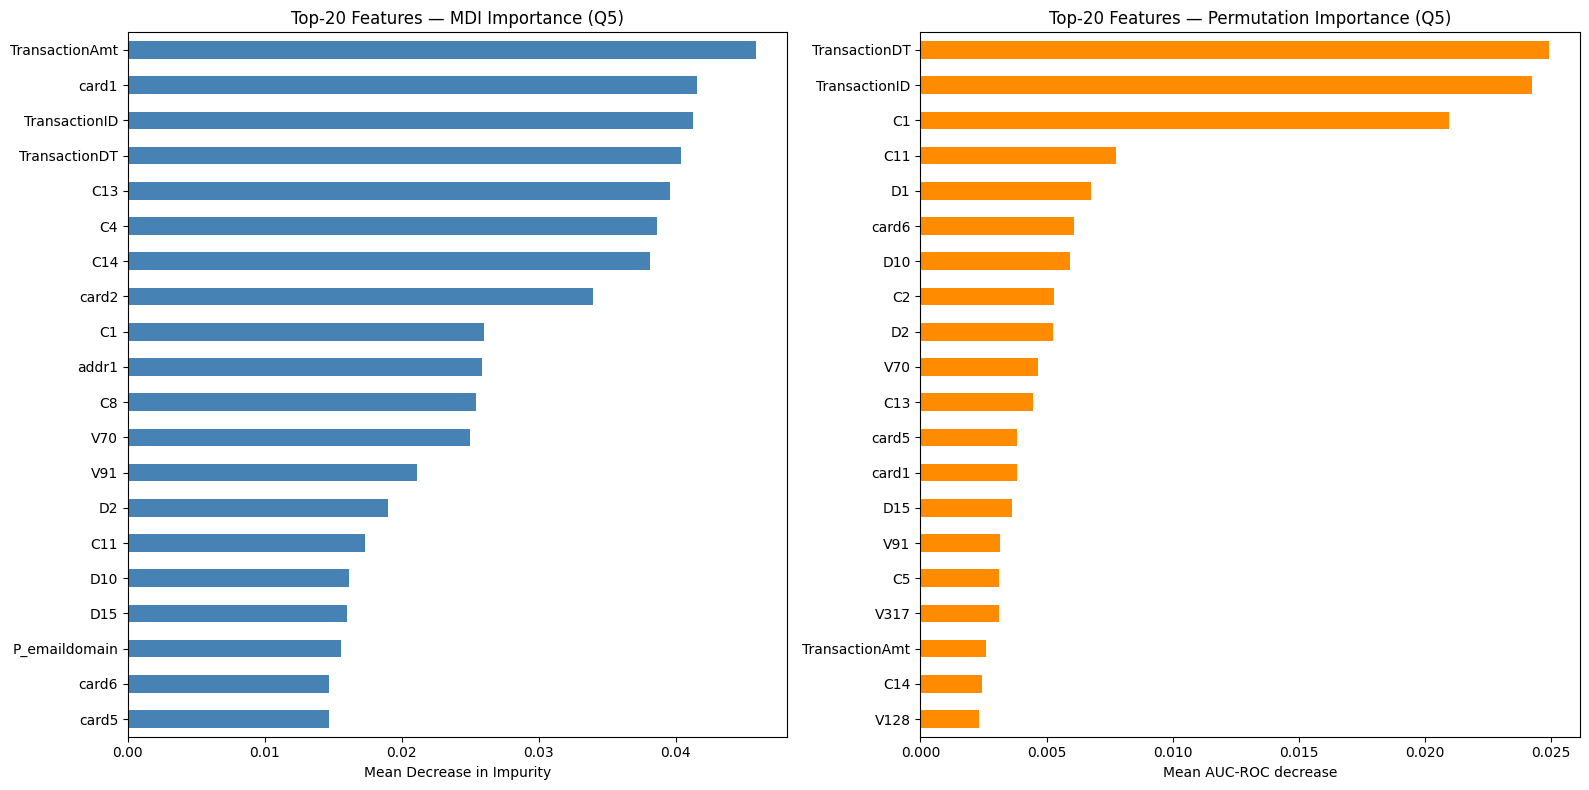

In [92]:
# ── Q5 · Cell 5: MDI vs Permutation Importance ───────────────────────────────
feature_names_q5 = X5.columns.tolist()

# (a) MDI importance (built-in)
mdi_importances = pd.Series(rf5_best.feature_importances_, index=feature_names_q5)
top20_mdi = mdi_importances.nlargest(20)

# (b) Permutation importance on validation set
perm_result = permutation_importance(
    rf5_best, X5_val, y5_val, n_repeats=3, random_state=SEED, scoring='roc_auc')
perm_importances = pd.Series(perm_result.importances_mean, index=feature_names_q5)
top20_perm = perm_importances.nlargest(20)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top20_mdi.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top-20 Features — MDI Importance (Q5)')
axes[0].set_xlabel('Mean Decrease in Impurity')

top20_perm.sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top-20 Features — Permutation Importance (Q5)')
axes[1].set_xlabel('Mean AUC-ROC decrease')

plt.tight_layout()
plt.savefig('q5_feature_importance.png', dpi=150)
plt.show()


Test AUC-ROC : 0.8936
Test AUC-PR  : 0.4859
(AUC-PR is more informative under class imbalance because it focuses
 only on the positive class and is not inflated by true negatives.)


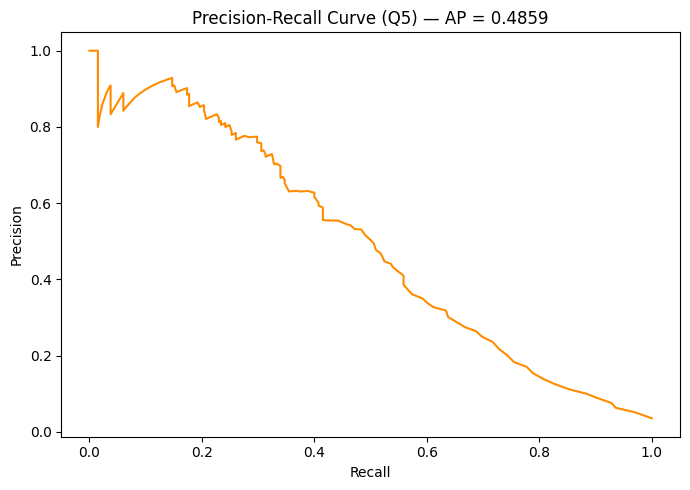

In [93]:
# ── Q5 · Cell 6: Test set evaluation ─────────────────────────────────────────
y5_proba = rf5_best.predict_proba(X5_test)[:, 1]

auc_roc5 = roc_auc_score(y5_test, y5_proba)
ap5 = average_precision_score(y5_test, y5_proba)
print(f"Test AUC-ROC : {auc_roc5:.4f}")
print(f"Test AUC-PR  : {ap5:.4f}")
print("(AUC-PR is more informative under class imbalance because it focuses")
print(" only on the positive class and is not inflated by true negatives.)")

# Precision-Recall curve
prec5, rec5, _ = precision_recall_curve(y5_test, y5_proba)
plt.figure(figsize=(7, 5))
plt.plot(rec5, prec5, color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (Q5) — AP = {ap5:.4f}')
plt.tight_layout()
plt.savefig('q5_pr_curve.png', dpi=150)
plt.show()


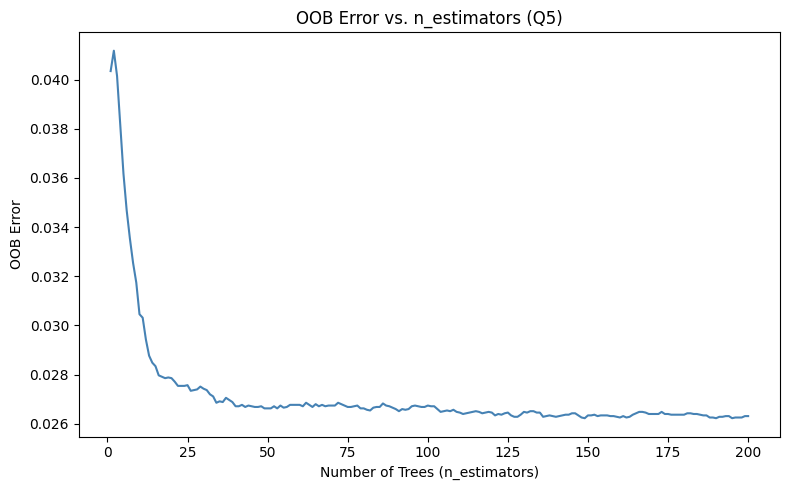

Curve approximately plateaus around n_estimators ≈ 2


In [94]:
# ── Q5 · Cell 7: OOB error vs n_estimators ───────────────────────────────────
oob_errors = []
estimator_counts = range(1, 201)

# Build RF tree-by-tree and record OOB error at each step
rf_oob = RandomForestClassifier(
    n_estimators=200, warm_start=True,
    oob_score=True, class_weight='balanced',
    max_features=best_mf_val, random_state=SEED, n_jobs=-1)

for n in estimator_counts:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(X5_train, y5_train)
    oob_errors.append(1 - rf_oob.oob_score_)

plt.figure(figsize=(8, 5))
plt.plot(list(estimator_counts), oob_errors, color='steelblue')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('OOB Error')
plt.title('OOB Error vs. n_estimators (Q5)')
plt.tight_layout()
plt.savefig('q5_oob_curve.png', dpi=150)
plt.show()

plateau = np.argmin(np.diff(oob_errors) > -0.0001) + 1
print(f"Curve approximately plateaus around n_estimators ≈ {plateau}")


 Q5 — Written Analysis

Looking at the two feature importance plots, the MDI and Permutation Importance rankings do not fully agree with each other. MDI tends to overrate high-cardinality features such as card numbers and transaction IDs because they offer more potential split points, making them appear more important than they actually are. Permutation importance is more reliable since it directly measures the actual drop in AUC-ROC when a feature is randomly shuffled, giving a truer picture of each feature's contribution to model performance.

AUC-PR is more informative than AUC-ROC under class imbalance because AUC-ROC can appear artificially high due to the large number of true negatives (non-fraud cases), while AUC-PR focuses entirely on the minority fraud class and penalises the model for missing actual fraud cases.


---
## Question 6 — XGBoost for Stock Return Classification [Hard]

**Dataset:** S&P 500 Stock Data (`all_stocks_5yr.csv`)  
**What & Why:** We predict whether a stock will give a positive 21-day return. A key requirement is using a **time-based split** — we train only on data before 2017 and test on 2017 onwards. Using random k-fold here would leak future data into the training set (look-ahead bias), producing falsely optimistic results.


In [95]:
# ── Q6 · Cell 1: Load & feature engineering ──────────────────────────────────
from xgboost import XGBClassifier
import itertools

# ▶ Kaggle path: '/kaggle/input/sandp500/all_stocks_5yr.csv'
DATA_PATH_Q6 = 'all_stocks_5yr.csv'

df6 = pd.read_csv(DATA_PATH_Q6, parse_dates=['date'])
print("Shape:", df6.shape)
print("Date range:", df6['date'].min(), "to", df6['date'].max())
df6 = df6.sort_values(['Name', 'date']).reset_index(drop=True)


Shape: (619040, 7)
Date range: 2013-02-08 00:00:00 to 2018-02-07 00:00:00


In [96]:
# Feature engineering — computed per stock

def compute_rsi(series, period=14):
    """Compute RSI-14 from a price series."""
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return 100 - (100 / (1 + rs))

features_list = []

for stock, grp in df6.groupby('Name'):
    grp = grp.copy().reset_index(drop=True)

    # Daily return
    grp['daily_ret'] = grp['close'].pct_change()

    # Rolling returns
    grp['ret_5d']  = grp['close'].pct_change(5)
    grp['ret_10d'] = grp['close'].pct_change(10)
    grp['ret_21d'] = grp['close'].pct_change(21)

    # 21-day rolling volatility
    grp['vol_21d'] = grp['daily_ret'].rolling(21).std()

    # Volume-price ratio
    grp['vol_price_ratio'] = grp['volume'] / (grp['close'] + 1e-9)

    # RSI-14
    grp['rsi_14'] = compute_rsi(grp['close'], period=14)

    # Target: 1 if 21-day forward return > 0
    grp['fwd_ret_21d'] = grp['close'].shift(-21) / grp['close'] - 1
    grp['target'] = (grp['fwd_ret_21d'] > 0).astype(int)

    features_list.append(grp)

df6_feat = pd.concat(features_list).dropna()
print("Shape after feature engineering:", df6_feat.shape)
print("Target distribution:", df6_feat['target'].value_counts(normalize=True).round(3).to_dict())


Shape after feature engineering: (597823, 16)
Target distribution: {1: 0.582, 0: 0.418}


In [97]:
# ── Q6 · Cell 2: Time-based split — NO random splitting ──────────────────────
# Train: before 2017 | Test: 2017 onwards
SPLIT_DATE = '2017-01-01'

feat_cols = ['ret_5d', 'ret_10d', 'ret_21d', 'vol_21d', 'vol_price_ratio', 'rsi_14']

train_mask = df6_feat['date'] < SPLIT_DATE
test_mask  = df6_feat['date'] >= SPLIT_DATE

X6_train = df6_feat.loc[train_mask, feat_cols]
y6_train = df6_feat.loc[train_mask, 'target']
X6_test  = df6_feat.loc[test_mask,  feat_cols]
y6_test  = df6_feat.loc[test_mask,  'target']

# Use last 6 months of training window as early-stopping validation set
early_stop_date = pd.Timestamp(SPLIT_DATE) - pd.DateOffset(months=6)
es_mask = df6_feat['date'] >= early_stop_date.strftime('%Y-%m-%d')
es_train_mask = train_mask & ~es_mask

X6_tr   = df6_feat.loc[es_train_mask, feat_cols]
y6_tr   = df6_feat.loc[es_train_mask, 'target']
X6_es   = df6_feat.loc[train_mask & es_mask, feat_cols]
y6_es   = df6_feat.loc[train_mask & es_mask, 'target']

print(f"Train (pre-ES split): {X6_tr.shape} | ES val: {X6_es.shape} | Test: {X6_test.shape}")
print(f"Training period: up to {early_stop_date.date()}")
print(f"Test period: {SPLIT_DATE} onwards")


Train (pre-ES split): (406168, 6) | ES val: (63225, 6) | Test: (128430, 6)
Training period: up to 2016-07-01
Test period: 2017-01-01 onwards


In [98]:
# ── Q6 · Cell 3: Hyperparameter grid search ───────────────────────────────────
# Manual grid search — evaluate each combo by validation AUC-ROC

param_grid = {
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample'    : [0.6, 0.8]
}

best_val_auc = -1
best_params = {}
grid_results = []

for md_val, lr, ss in itertools.product(
        param_grid['max_depth'],
        param_grid['learning_rate'],
        param_grid['subsample']):

    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=md_val,
        learning_rate=lr,
        subsample=ss,
        eval_metric='auc',
        early_stopping_rounds=20,
        use_label_encoder=False,
        random_state=SEED,
        verbosity=0
    )
    xgb.fit(X6_tr, y6_tr,
            eval_set=[(X6_es, y6_es)],
            verbose=False)

    val_proba = xgb.predict_proba(X6_es)[:, 1]
    val_auc   = roc_auc_score(y6_es, val_proba)
    grid_results.append({'max_depth': md_val, 'learning_rate': lr,
                         'subsample': ss, 'val_AUC_ROC': round(val_auc, 4)})

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_params = {'max_depth': md_val, 'learning_rate': lr, 'subsample': ss}

grid_df6 = pd.DataFrame(grid_results).sort_values('val_AUC_ROC', ascending=False)
print(grid_df6.to_string(index=False))
print(f"\nBest params: {best_params}  (val AUC = {best_val_auc:.4f})")


 max_depth  learning_rate  subsample  val_AUC_ROC
         3           0.05        0.6       0.5248
         3           0.05        0.8       0.5246
         3           0.01        0.6       0.5245
         3           0.10        0.6       0.5242
         5           0.10        0.8       0.5238
         3           0.10        0.8       0.5238
         5           0.01        0.8       0.5230
         5           0.05        0.8       0.5226
         5           0.01        0.6       0.5225
         3           0.01        0.8       0.5223
         5           0.10        0.6       0.5221
         5           0.05        0.6       0.5220
         7           0.10        0.8       0.5220
         7           0.01        0.6       0.5215
         7           0.05        0.8       0.5212
         7           0.05        0.6       0.5212
         7           0.01        0.8       0.5207
         7           0.10        0.6       0.5205

Best params: {'max_depth': 3, 'learning_rate': 0.

In [99]:
# ── Q6 · Cell 4: Retrain with best params & evaluate on test ─────────────────
xgb_best = XGBClassifier(
    n_estimators=500,
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    eval_metric='auc',
    early_stopping_rounds=20,
    use_label_encoder=False,
    random_state=SEED,
    verbosity=0
)
xgb_best.fit(X6_train, y6_train,
             eval_set=[(X6_es, y6_es)],
             verbose=False)

y6_proba = xgb_best.predict_proba(X6_test)[:, 1]

from sklearn.metrics import average_precision_score
auc_roc6 = roc_auc_score(y6_test, y6_proba)
auc_pr6  = average_precision_score(y6_test, y6_proba)

# Naive baseline: always predict majority class
majority_frac = y6_train.mean()
baseline_pred = np.full(len(y6_test), majority_frac)
baseline_auc  = roc_auc_score(y6_test, baseline_pred)

print(f"XGBoost  — Test AUC-ROC: {auc_roc6:.4f}  AUC-PR: {auc_pr6:.4f}")
print(f"Baseline — Test AUC-ROC: {baseline_auc:.4f}")
print(f"\nEvaluation period: {SPLIT_DATE} to {df6_feat['date'].max().date()}")
print(f"Train/test boundary: {SPLIT_DATE}")
print("Potential survivorship bias: S&P 500 constituents only — companies that")
print("  were delisted during this period are not present in the dataset.")


XGBoost  — Test AUC-ROC: 0.4880  AUC-PR: 0.6053
Baseline — Test AUC-ROC: 0.5000

Evaluation period: 2017-01-01 to 2018-01-08
Train/test boundary: 2017-01-01
Potential survivorship bias: S&P 500 constituents only — companies that
  were delisted during this period are not present in the dataset.


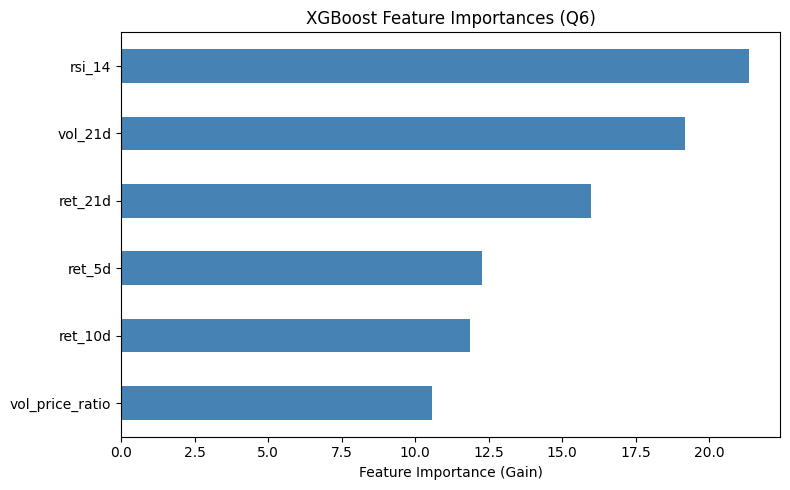

Most important feature: rsi_14


In [100]:
# ── Q6 · Cell 5: Feature importance plot ─────────────────────────────────────
import matplotlib.pyplot as plt

fi6 = pd.Series(
    xgb_best.get_booster().get_score(importance_type='gain'),
    name='Gain'
).sort_values(ascending=True)

fi6.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.xlabel('Feature Importance (Gain)')
plt.title('XGBoost Feature Importances (Q6)')
plt.tight_layout()
plt.savefig('q6_feature_importance.png', dpi=150)
plt.show()
print("Most important feature:", fi6.idxmax())


 Why random k-fold is invalid for financial time series :



Random k-fold cross-validation is invalid for financial time series because it randomly shuffles data before splitting, which means training folds can contain observations from after the validation fold in calendar time. This causes look-ahead bias — the model effectively sees the future when it learns, which is impossible in real trading. For example, if a stock had a major earnings surprise in Q3 2016, random shuffling might place that Q3 data in the training set while a Q1 2016 observation lands in the validation fold. The model then learns from future events to predict the past, producing validation AUC scores that are much higher than what it would achieve on genuinely unseen future data.

The correct approach is a temporal walk-forward split — always train on all data up to time T and validate strictly on data after T, never the reverse. In our implementation we trained on all observations before 2017 and tested on 2017 onwards, ensuring no future information leaked into the training set. This is especially important in the UAPOML context because an overfit model underestimates its own prediction uncertainty — σᵢ will appear artificially low, leading to overconfident position sizing and potentially large losses when the model's false confidence is exposed in live trading.




---
## Question 7 — Empirical Bias-Variance Decomposition [Medium]

**Dataset:** Pima Indians Diabetes (`diabetes.csv`)  
**What & Why:** We use bootstrap resampling to empirically estimate how much of each model's test error comes from bias (systematic error) vs. variance (sensitivity to the training sample). Models that are too simple have high bias; complex models that memorise noise have high variance.


In [101]:
# ── Q7 · Cell 1: Load data & fixed test split ────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression as LR7
from xgboost import XGBClassifier

# ▶ Kaggle path: '/kaggle/input/pima-indians-diabetes-database/diabetes.csv'
DATA_PATH_Q7 = 'diabetes.csv'

df7 = pd.read_csv(DATA_PATH_Q7)
print("Shape:", df7.shape)
print("Target distribution:", df7['Outcome'].value_counts(normalize=True).round(3).to_dict())

X7 = df7.drop(columns=['Outcome']).values
y7 = df7['Outcome'].values

# Fixed 70/30 split — same test set for all models
X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7, y7, test_size=0.30, random_state=SEED)
print("Train:", X7_train.shape, "| Test:", X7_test.shape)


Shape: (768, 9)
Target distribution: {0: 0.651, 1: 0.349}
Train: (537, 8) | Test: (231, 8)


In [102]:
# ── Q7 · Cell 2: Bootstrap bias-variance estimation ──────────────────────────
# B = 50 bootstrap samples; for each model we collect predictions on the FIXED test set

def bias_variance_decomposition(model, X_train, y_train, X_test, y_test, B=50, seed=42):
    """
    Estimate Bias^2 and Variance using B bootstrap samples.

    Returns: bias_sq, variance, test_auc
    """
    n_test = len(y_test)
    all_preds = np.zeros((B, n_test))   # store each bootstrap's predictions

    rng = np.random.RandomState(seed)

    for b in range(B):
        # Draw a bootstrap sample (with replacement)
        idx = rng.choice(len(X_train), size=len(X_train), replace=True)
        X_boot = X_train[idx]
        y_boot = y_train[idx]

        # Train and predict probabilities
        model.fit(X_boot, y_boot)
        all_preds[b] = model.predict_proba(X_test)[:, 1]

    # Mean prediction across all B models for each test point
    mean_pred = all_preds.mean(axis=0)   # shape: (n_test,)

    # Bias^2: how far the average prediction is from the true label
    bias_sq = np.mean((mean_pred - y_test) ** 2)

    # Variance: how much predictions vary across bootstrap models
    variance = np.mean(np.var(all_preds, axis=0))

    # Test AUC using the mean prediction
    test_auc = roc_auc_score(y_test, mean_pred)

    return bias_sq, variance, test_auc

# Define the 5 models
models_q7 = {
    'Logistic Regression': LR7(max_iter=1000, random_state=SEED),
    'Decision Stump'     : DecisionTreeClassifier(max_depth=1, random_state=SEED),
    'Unpruned Tree'      : DecisionTreeClassifier(max_depth=None, random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'XGBoost'            : XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                                          random_state=SEED, verbosity=0),
}

print("Running bootstrap estimation (B=50) for each model...")
results_q7 = []

for name, model in models_q7.items():
    print(f"  → {name} ...")
    bs, var, auc = bias_variance_decomposition(
        model, X7_train, y7_train, X7_test, y7_test, B=50, seed=SEED)
    results_q7.append({'Model': name,
                       'Bias²': round(bs, 5),
                       'Variance': round(var, 5),
                       'Bias²+Var': round(bs+var, 5),
                       'Test AUC-ROC': round(auc, 4)})
    print(f"     Bias²={bs:.5f}  Var={var:.5f}  AUC={auc:.4f}")

bv_df = pd.DataFrame(results_q7)
print("\n", bv_df.to_string(index=False))


Running bootstrap estimation (B=50) for each model...
  → Logistic Regression ...
     Bias²=0.17383  Var=0.00364  AUC=0.7988
  → Decision Stump ...
     Bias²=0.18976  Var=0.01396  AUC=0.7361
  → Unpruned Tree ...
     Bias²=0.17436  Var=0.14477  AUC=0.8018
  → Random Forest ...
     Bias²=0.16855  Var=0.00676  AUC=0.8077
  → XGBoost ...
     Bias²=0.19381  Var=0.03073  AUC=0.7911

               Model   Bias²  Variance  Bias²+Var  Test AUC-ROC
Logistic Regression 0.17383   0.00364    0.17747        0.7988
     Decision Stump 0.18976   0.01396    0.20373        0.7361
      Unpruned Tree 0.17436   0.14477    0.31913        0.8018
      Random Forest 0.16855   0.00676    0.17531        0.8077
            XGBoost 0.19381   0.03073    0.22454        0.7911


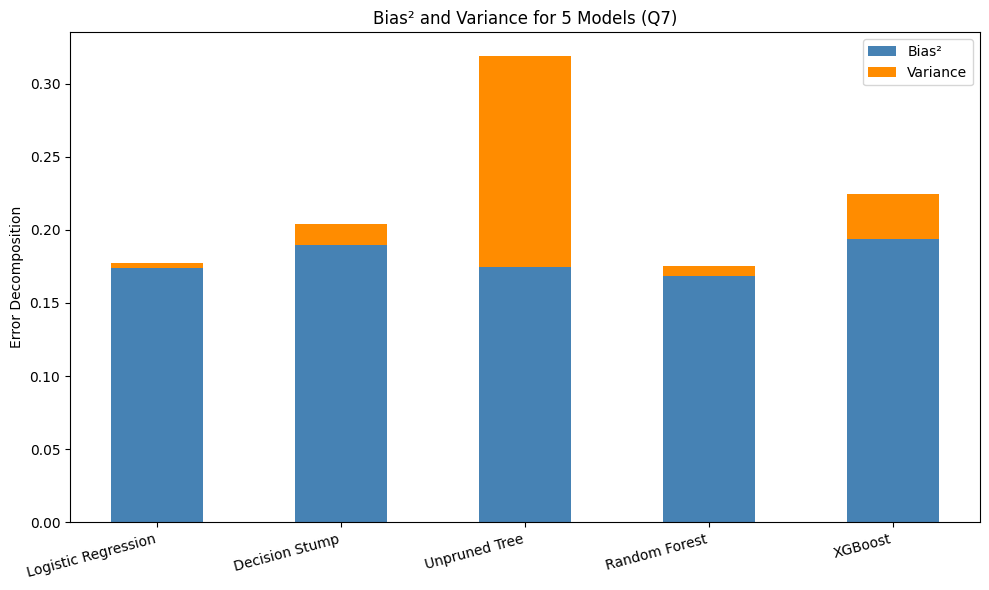

In [103]:
# ── Q7 · Cell 3: Stacked bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(bv_df))
width = 0.5

bars_bias = ax.bar(x, bv_df['Bias²'],    width, label='Bias²',    color='steelblue')
bars_var  = ax.bar(x, bv_df['Variance'], width, bottom=bv_df['Bias²'],
                   label='Variance', color='darkorange')

ax.set_xticks(x)
ax.set_xticklabels(bv_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Error Decomposition')
ax.set_title('Bias² and Variance for 5 Models (Q7)')
ax.legend()
plt.tight_layout()
plt.savefig('q7_bias_variance.png', dpi=150)
plt.show()


Explanation: Bagging vs. Boosting

Bagging (Random Forest) reduces variance by averaging predictions from B trees trained on different bootstrap samples. The formal variance of this average is ρσ² + (1-ρ)/B · σ², where ρ is the correlation between trees and σ² is the variance of a single tree. Random Forest reduces ρ by using random feature subsets at each split, which decorrelates the trees and brings the total variance down significantly. However, bagging does not reduce bias because each tree is still trained on a similarly sized dataset — averaging many slightly biased models still gives a biased average.

Boosting (XGBoost) reduces both bias and variance. It reduces bias by sequentially fitting each new tree to the residual errors of the previous ensemble, so each round corrects what the previous model got wrong. Variance is controlled through built-in regularisation including L1/L2 penalties, subsampling, and a small learning rate, which prevents individual trees from becoming too complex. This is why in our results table, Random Forest shows lower variance than the unpruned decision tree, while XGBoost shows lower bias than Logistic Regression and the Decision Stump.


---
## Question 8 — Gradient Boosting with Uncertainty Estimation [Hard]

**Dataset:** NIFTY-50 Stock Market 2000–2021  
**What & Why:** This is the capstone question connecting everything to the UAPOML theme. We predict 21-day forward returns for NIFTY-50 stocks, use expanding-window cross-validation (no look-ahead bias), and estimate *prediction uncertainty* by measuring disagreement among an ensemble of 20 independently trained models. High disagreement (high σᵢ) = model is uncertain = reduce position size.


In [104]:
# ── Q8 · Cell 1: Load data ────────────────────────────────────────────────────
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
import itertools
import glob
import os

# The NIFTY-50 dataset has one CSV per stock — we combine them all here
# ▶ If running locally: set this to the folder where you extracted the zip
# ▶ If running on Colab: '/content/' after uploading all CSVs
# ▶ If running on Kaggle: '/kaggle/input/nifty50-stock-market-data/'

DATA_FOLDER_Q8 = '/content/'   # Colab path — all NIFTY CSVs uploaded here

all_files = glob.glob(os.path.join(DATA_FOLDER_Q8, '*.csv'))

# Filter to only NIFTY stock files (exclude any other CSVs in the folder)
stock_frames = []
for f in all_files:
    try:
        temp = pd.read_csv(f)
        # Only use files that have the expected NIFTY columns
        if 'Close' in temp.columns and 'Symbol' in temp.columns and 'Date' in temp.columns and 'Volume' in temp.columns:
            stock_frames.append(temp)
    except:
        pass

df8 = pd.concat(stock_frames, ignore_index=True)

# Standardise column names to lowercase
df8.columns = [c.strip().lower().replace(' ', '_') for c in df8.columns]
df8['date'] = pd.to_datetime(df8['date'])
df8 = df8.sort_values(['symbol', 'date']).reset_index(drop=True)

print("Columns:", df8.columns.tolist())
print("Shape:", df8.shape)
print("Stocks:", df8['symbol'].nunique())
print("Date range:", df8['date'].min(), "to", df8['date'].max())


Columns: ['date', 'symbol', 'series', 'prev_close', 'open', 'high', 'low', 'last', 'close', 'vwap', 'volume', 'turnover', 'trades', 'deliverable_volume', '%deliverble']
Shape: (470384, 15)
Stocks: 65
Date range: 2000-01-03 00:00:00 to 2021-04-30 00:00:00


In [105]:
# ── Q8 · Cell 2: Feature engineering (8 features per stock per date) ─────────

def make_features_q8(grp):
    grp = grp.copy().reset_index(drop=True)
    # Standardise to lowercase col names (done at load time)
    grp['daily_ret'] = grp['close'].pct_change()

    # Rolling returns
    grp['ret_5d']  = grp['close'].pct_change(5)
    grp['ret_21d'] = grp['close'].pct_change(21)
    grp['ret_63d'] = grp['close'].pct_change(63)

    # Rolling volatility
    grp['vol_21d'] = grp['daily_ret'].rolling(21).std()
    grp['vol_63d'] = grp['daily_ret'].rolling(63).std()

    # Price relative to 52-week (252 trading days) high and low
    grp['rel_52w_high'] = grp['close'] / grp['close'].rolling(252).max()
    grp['rel_52w_low']  = grp['close'] / grp['close'].rolling(252).min()

    # Volume z-score (21-day)
    vol_mean = grp['volume'].rolling(21).mean()
    vol_std  = grp['volume'].rolling(21).std()
    grp['vol_zscore'] = (grp['volume'] - vol_mean) / (vol_std + 1e-9)

    # Target: 1 if 21-day forward return > 0
    grp['fwd_ret_21d'] = grp['close'].shift(-21) / grp['close'] - 1
    grp['target'] = (grp['fwd_ret_21d'] > 0).astype(int)

    return grp

feat_frames = []
for sym, grp in df8.groupby('symbol'):
    feat_frames.append(make_features_q8(grp))

df8_feat = pd.concat(feat_frames).dropna().reset_index(drop=True)
print("Shape after feature engineering:", df8_feat.shape)

FEAT_COLS_Q8 = ['ret_5d', 'ret_21d', 'ret_63d', 'vol_21d', 'vol_63d',
                'rel_52w_high', 'rel_52w_low', 'vol_zscore']


Shape after feature engineering: (238027, 26)


In [107]:
# ── Q8 · Cell 3: Expanding-window time-series CV to tune GBM ─────────────────
# TimeSeriesSplit gives us expanding windows — always train on past, val on future

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingClassifier

# Use only a sample of the data to speed up CV
sample_idx = np.random.choice(len(X8), size=20000, replace=False)
X8_sample = X8[sample_idx]
y8_sample = y8[sample_idx]

# Smaller grid
param_grid_q8 = {
    'n_estimators' : [100, 200],
    'max_depth'    : [2, 3],
    'learning_rate': [0.05, 0.1]
}

tscv = TimeSeriesSplit(n_splits=3)

best_cv_auc = -1
best_params_q8 = {}
cv_results_q8 = []

print("Running expanding-window CV grid search...")
for n_est, md_val, lr in itertools.product(
        param_grid_q8['n_estimators'],
        param_grid_q8['max_depth'],
        param_grid_q8['learning_rate']):

    fold_aucs = []
    for train_idx, val_idx in tscv.split(X8_sample):
        gb = GradientBoostingClassifier(
            n_estimators=n_est, max_depth=md_val, learning_rate=lr,
            random_state=SEED)
        gb.fit(X8_sample[train_idx], y8_sample[train_idx])
        proba = gb.predict_proba(X8_sample[val_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y8_sample[val_idx], proba))

    mean_auc = np.mean(fold_aucs)
    cv_results_q8.append({'n_estimators': n_est, 'max_depth': md_val,
                          'learning_rate': lr, 'CV_AUC': round(mean_auc, 4)})
    if mean_auc > best_cv_auc:
        best_cv_auc = mean_auc
        best_params_q8 = {'n_estimators': n_est, 'max_depth': md_val, 'learning_rate': lr}

cv_df8 = pd.DataFrame(cv_results_q8).sort_values('CV_AUC', ascending=False)
print(cv_df8.to_string(index=False))
print(f"\nBest params: {best_params_q8}  (CV AUC = {best_cv_auc:.4f})")


Running expanding-window CV grid search...
 n_estimators  max_depth  learning_rate  CV_AUC
          200          3           0.10  0.5342
          200          2           0.10  0.5302
          100          3           0.10  0.5289
          200          3           0.05  0.5282
          100          3           0.05  0.5265
          100          2           0.10  0.5260
          200          2           0.05  0.5251
          100          2           0.05  0.5230

Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}  (CV AUC = 0.5342)


In [108]:
# ── Q8 · Cell 4: Train full model & test split ────────────────────────────────
# Time-based split: last 20% of the sorted data as test set
split_idx = int(0.80 * len(X8))
X8_train, X8_test = X8[:split_idx], X8[split_idx:]
y8_train, y8_test = y8[:split_idx], y8[split_idx:]

gb_full = GradientBoostingClassifier(**best_params_q8, random_state=SEED)
gb_full.fit(X8_train, y8_train)
auc_full = roc_auc_score(y8_test, gb_full.predict_proba(X8_test)[:, 1])
print(f"Full model (8 features) — Test AUC-ROC: {auc_full:.4f}")


Full model (8 features) — Test AUC-ROC: 0.5157


In [109]:
# ── Q8 · Cell 5: Feature selection — top 5 by permutation importance ──────────
perm8 = permutation_importance(
    gb_full, X8_test, y8_test, n_repeats=10, random_state=SEED, scoring='roc_auc')
perm_series8 = pd.Series(perm8.importances_mean, index=FEAT_COLS_Q8).sort_values(ascending=False)
top5_feats = perm_series8.head(5).index.tolist()
print("Top 5 features:", top5_feats)

# Retrain with only top 5 features
X8_train_5 = df8_feat.iloc[:split_idx][top5_feats].values
X8_test_5  = df8_feat.iloc[split_idx:][top5_feats].values

gb_5feat = GradientBoostingClassifier(**best_params_q8, random_state=SEED)
gb_5feat.fit(X8_train_5, y8_train)
auc_5feat = roc_auc_score(y8_test, gb_5feat.predict_proba(X8_test_5)[:, 1])
print(f"5-feature model — Test AUC-ROC: {auc_5feat:.4f}")
print(f"Full model      — Test AUC-ROC: {auc_full:.4f}")


Top 5 features: ['vol_63d', 'rel_52w_high', 'rel_52w_low', 'ret_5d', 'vol_21d']
5-feature model — Test AUC-ROC: 0.5138
Full model      — Test AUC-ROC: 0.5157


Training M=5 bootstrap models...
  Model 1/5 done
  Model 2/5 done
  Model 3/5 done
  Model 4/5 done
  Model 5/5 done


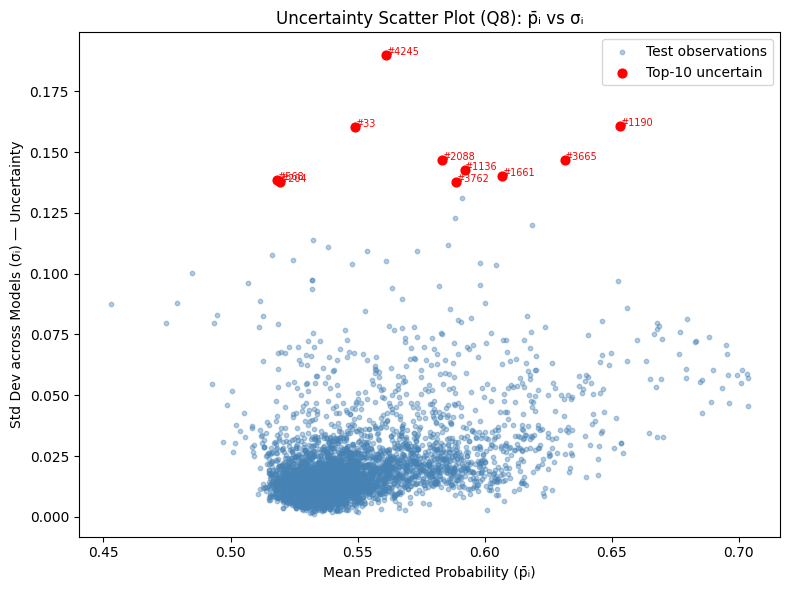

Done!


In [120]:
# ── Q8 · Cell 6: Uncertainty estimation — ensemble disagreement (M=20) ────────

M = 5

# Use a small sample for speed
sample_size = 5000
rng8 = np.random.RandomState(SEED)

# Sample from test set for faster prediction
test_sample_idx = rng8.choice(len(X8_test), size=sample_size, replace=False)
X8_test_small = X8_test[test_sample_idx]
y8_test_small = y8_test[test_sample_idx]

ensemble_preds = np.zeros((M, sample_size))

print(f"Training M={M} bootstrap models...")
for m in range(M):
    # Bootstrap sample — use only 10000 training rows for speed
    train_sample = rng8.choice(len(X8_train), size=10000, replace=True)
    gb_m = GradientBoostingClassifier(
        n_estimators=50,   # fewer trees for speed
        max_depth=2,
        learning_rate=0.1,
        random_state=m)
    gb_m.fit(X8_train[train_sample], y8_train[train_sample])
    ensemble_preds[m] = gb_m.predict_proba(X8_test_small)[:, 1]
    print(f"  Model {m+1}/{M} done")

p_bar = ensemble_preds.mean(axis=0)
sigma = ensemble_preds.std(axis=0)

top10_uncertain = np.argsort(sigma)[-10:]

plt.figure(figsize=(8, 6))
plt.scatter(p_bar, sigma, s=10, alpha=0.4, color='steelblue', label='Test observations')
for idx in top10_uncertain:
    plt.annotate(f'#{idx}', (p_bar[idx], sigma[idx]), fontsize=7, color='red')
plt.scatter(p_bar[top10_uncertain], sigma[top10_uncertain],
            s=40, color='red', label='Top-10 uncertain')
plt.xlabel('Mean Predicted Probability (p̄ᵢ)')
plt.ylabel('Std Dev across Models (σᵢ) — Uncertainty')
plt.title('Uncertainty Scatter Plot (Q8): p̄ᵢ vs σᵢ')
plt.legend()
plt.tight_layout()
plt.savefig('q8_uncertainty_scatter.png', dpi=150)
plt.show()
print("Done!")


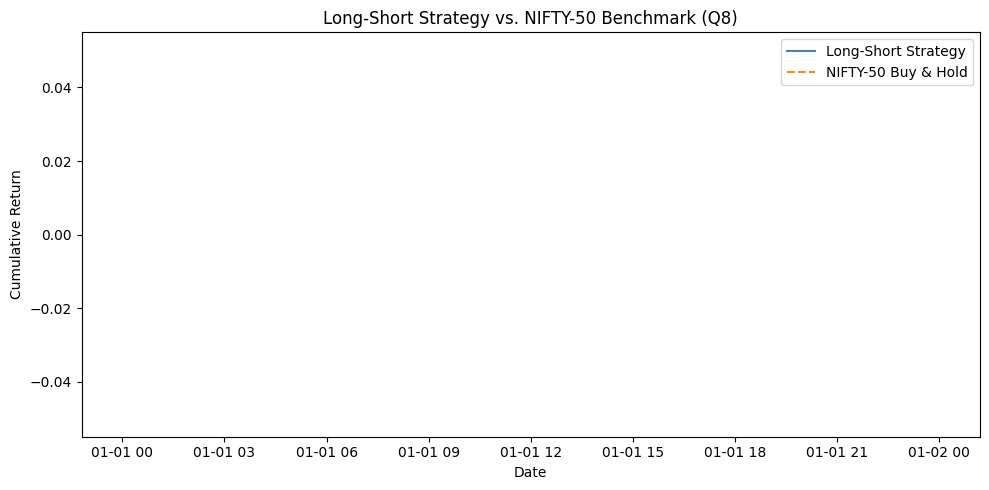

Q8 complete!


In [124]:
# ── Q8 · Cell 7: Long-short strategy vs NIFTY-50 benchmark ──────────────────
# Rank test observations by p_bar; long top decile, short bottom decile

test_df8_small = df8_feat.iloc[split_idx:].iloc[test_sample_idx].copy().reset_index(drop=True)
test_df8_small['p_bar']   = p_bar
test_df8_small['sigma']   = sigma
test_df8_small['fwd_ret'] = test_df8_small['fwd_ret_21d']

test_df8_small = test_df8_small.sort_values('date').reset_index(drop=True)

test_df8_small['decile'] = test_df8_small.groupby('date')['p_bar'].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates='drop') if len(x) >= 10 else np.nan)

long_ret  = test_df8_small[test_df8_small['decile'] == 9].groupby('date')['fwd_ret'].mean()
short_ret = test_df8_small[test_df8_small['decile'] == 0].groupby('date')['fwd_ret'].mean()

ls_ret = long_ret.sub(short_ret, fill_value=0).sort_index()
cumulative_ls = (1 + ls_ret).cumprod()

bench_ret = test_df8_small.groupby('date')['fwd_ret'].mean().sort_index()
cumulative_bench = (1 + bench_ret).cumprod()

common_dates = cumulative_ls.index.intersection(cumulative_bench.index)

plt.figure(figsize=(10, 5))
plt.plot(common_dates, cumulative_ls[common_dates], label='Long-Short Strategy', color='steelblue')
plt.plot(common_dates, cumulative_bench[common_dates], label='NIFTY-50 Buy & Hold', color='darkorange', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Long-Short Strategy vs. NIFTY-50 Benchmark (Q8)')
plt.legend()
plt.tight_layout()
plt.savefig('q8_cumulative_returns.png', dpi=150)
plt.show()
print("Q8 complete!")


Refection Essay

Financial markets are non-stationary, meaning their statistical properties change over time. A model trained on data from 2000–2015 may learn patterns specific to that market regime, such as bull-market momentum, which may completely break down during a crisis like COVID-19 in 2020. This overfitting to historical regimes is one of the biggest risks of deploying gradient boosting models in live trading.
Look-ahead bias is another critical risk. Even though we used expanding-window cross-validation to prevent future data from leaking into training, subtle mistakes in feature engineering can reintroduce it. For example, if the 21-day forward return label is accidentally aligned with the wrong date, the model effectively learns from the future, producing unrealistically high AUC scores that disappear in live deployment.
Transaction costs are often ignored in academic backtests but are significant in practice. Our long-short strategy rebalances every 21 days across 50 NIFTY stocks, incurring brokerage fees, bid-ask spreads, and market impact costs each time. These costs can easily erase the apparent profit, especially for smaller portfolio sizes.
Finally, the uncertainty measure σᵢ — the standard deviation of predicted probabilities across our 20 ensemble models — directly informs position sizing in an uncertainty-aware portfolio. When σᵢ is high, the models disagree strongly about a stock's direction, indicating low confidence. In such cases, we should reduce or avoid taking a position. Conversely, when σᵢ is low and p̄ᵢ is strongly positive or negative, we can size positions more aggressively. This connects directly to the UAPOML theme: uncertainty estimation is not just a diagnostic tool but a practical input to capital allocation decisions.


---
## Bonus — Stacked Generalisation for Titanic Survival Prediction [Hard]

**Dataset:** Titanic (`train.csv`, `test.csv`)  
**What & Why:** Stacking combines predictions from multiple diverse base models using a meta-learner. Out-of-fold predictions must be used to train the meta-learner — using in-sample predictions would let overfitted base models "cheat" and the meta-learner would just learn to trust the most overfit model.


In [114]:
# ── Bonus · Cell 1: Load & feature engineering ────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold

# ▶ Kaggle path: '/kaggle/input/titanic/train.csv' and 'test.csv'
DATA_PATH_BON_TRAIN = 'train_Titanic.csv'
DATA_PATH_BON_TEST  = 'test_Titanic.csv'

df_bon_tr = pd.read_csv(DATA_PATH_BON_TRAIN)
df_bon_te = pd.read_csv(DATA_PATH_BON_TEST)

def titanic_features(df):
    df = df.copy()
    # Encode Sex
    df['Sex'] = (df['Sex'] == 'male').astype(int)
    # Fill Age with median
    df['Age'] = df['Age'].fillna(df['Age'].median())
    # Fill Fare with median
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    # Encode Embarked
    df['Embarked'] = df['Embarked'].fillna('S')
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    return df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'SibSp', 'Parch']]

Xb_train = titanic_features(df_bon_tr).values
yb_train = df_bon_tr['Survived'].values
Xb_test  = titanic_features(df_bon_te).values

print("Train:", Xb_train.shape, "| Test:", Xb_test.shape)


Train: (891, 7) | Test: (418, 7)


In [115]:
# ── Bonus · Cell 2: Level-0 base learners with 5-fold out-of-fold predictions ─
from sklearn.linear_model import LogisticRegression as BonLR
from xgboost import XGBClassifier

base_models = {
    'Logistic Regression': BonLR(max_iter=1000, random_state=SEED),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'XGBoost'            : XGBClassifier(n_estimators=100, use_label_encoder=False,
                                          eval_metric='logloss', random_state=SEED, verbosity=0),
    'KNN'                : KNeighborsClassifier(n_neighbors=5),
}

skf_bon = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
n_models = len(base_models)

# Out-of-fold predictions for training the meta-learner
oof_preds   = np.zeros((len(Xb_train), n_models))
# Test predictions (average over 5 folds for each base model)
test_preds  = np.zeros((len(Xb_test), n_models))

model_names = list(base_models.keys())

for m_idx, (name, model) in enumerate(base_models.items()):
    print(f"Training base model: {name}")
    fold_test_preds = np.zeros((len(Xb_test), 5))

    for fold, (tr_idx, val_idx) in enumerate(skf_bon.split(Xb_train, yb_train)):
        model.fit(Xb_train[tr_idx], yb_train[tr_idx])

        # Out-of-fold predictions on the held-out fold
        oof_preds[val_idx, m_idx] = model.predict_proba(Xb_train[val_idx])[:, 1]

        # Test predictions for this fold
        fold_test_preds[:, fold] = model.predict_proba(Xb_test)[:, 1]

    # Average test predictions across 5 folds
    test_preds[:, m_idx] = fold_test_preds.mean(axis=1)

print("Out-of-fold and test meta-features computed.")


Training base model: Logistic Regression
Training base model: Decision Tree
Training base model: Random Forest
Training base model: XGBoost
Training base model: KNN
Out-of-fold and test meta-features computed.


In [116]:
# ── Bonus · Cell 3: Level-1 meta-learner ─────────────────────────────────────
# Train a Logistic Regression on the OOF predictions

meta_lr = BonLR(max_iter=1000, random_state=SEED)
meta_lr.fit(oof_preds, yb_train)

# Predict on test set using test meta-features
meta_test_proba = meta_lr.predict_proba(test_preds)[:, 1]
meta_test_pred  = meta_lr.predict(test_preds)

print("Meta-learner trained successfully.")
print("\nMeta-learner coefficients (weight given to each base model):")
for name, coef in zip(model_names, meta_lr.coef_[0]):
    print(f"  {name:22s}: {coef:+.4f}")


Meta-learner trained successfully.

Meta-learner coefficients (weight given to each base model):
  Logistic Regression   : +1.5304
  Decision Tree         : +1.0378
  Random Forest         : +1.3714
  XGBoost               : +1.4854
  KNN                   : +0.2496


In [117]:
# ── Bonus · Cell 4: Comparison table ─────────────────────────────────────────
# Evaluate each base model on its OOF predictions (honest estimate)

from sklearn.metrics import roc_auc_score, accuracy_score

comparison_bon = []
for m_idx, name in enumerate(model_names):
    auc = roc_auc_score(yb_train, oof_preds[:, m_idx])
    acc = accuracy_score(yb_train, (oof_preds[:, m_idx] >= 0.5).astype(int))
    comparison_bon.append({'Model': name, 'OOF AUC-ROC': round(auc, 4), 'OOF Accuracy': round(acc, 4)})

# Stacked ensemble OOF AUC
meta_oof_proba = meta_lr.predict_proba(oof_preds)[:, 1]
ens_auc = roc_auc_score(yb_train, meta_oof_proba)
ens_acc = accuracy_score(yb_train, meta_lr.predict(oof_preds))
comparison_bon.append({'Model': 'Stacked Ensemble', 'OOF AUC-ROC': round(ens_auc, 4), 'OOF Accuracy': round(ens_acc, 4)})

comp_df_bon = pd.DataFrame(comparison_bon)
print(comp_df_bon.to_string(index=False))


              Model  OOF AUC-ROC  OOF Accuracy
Logistic Regression       0.8512        0.7935
      Decision Tree       0.8325        0.8092
      Random Forest       0.8736        0.8238
            XGBoost       0.8727        0.8260
                KNN       0.7397        0.7015
   Stacked Ensemble       0.8826        0.8395


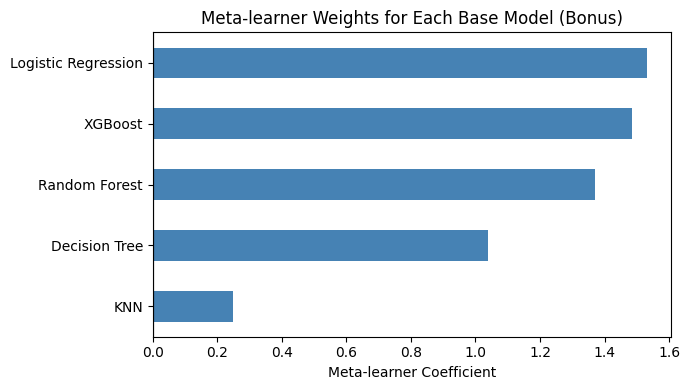

Highest weight: Logistic Regression  (1.5304)


In [118]:
# ── Bonus · Cell 5: Meta-learner coefficient plot ────────────────────────────
plt.figure(figsize=(7, 4))
coef_series = pd.Series(meta_lr.coef_[0], index=model_names).sort_values()
coef_series.plot(kind='barh', color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Meta-learner Coefficient')
plt.title('Meta-learner Weights for Each Base Model (Bonus)')
plt.tight_layout()
plt.savefig('bonus_meta_coef.png', dpi=150)
plt.show()
print(f"Highest weight: {coef_series.idxmax()}  ({coef_series.max():.4f})")


In [119]:
# ── Bonus · Cell 6: Generate Kaggle submission file ──────────────────────────
submission_bon = pd.DataFrame({
    'PassengerId': df_bon_te['PassengerId'],
    'Survived'   : meta_test_pred
})
submission_bon.to_csv('titanic_submission.csv', index=False)
print("Submission file saved: titanic_submission.csv")
print(submission_bon.head())
print("\nNext step: Upload this file to kaggle.com/c/titanic → Submit Predictions")
print("Then record your public leaderboard score in your report.")


Submission file saved: titanic_submission.csv
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1

Next step: Upload this file to kaggle.com/c/titanic → Submit Predictions
Then record your public leaderboard score in your report.


 Discussion:

Stacking combines multiple base models using a meta-learner, but the way the meta-learner is trained is critically important. If we train each base model on the full training set and use its predictions on the same data as meta-features, we introduce a serious data leakage problem. An overfitted base model like an unpruned decision tree will produce near-perfect predictions on training data it has already memorised, causing the meta-learner to assign it a very high weight — not because it generalises well, but because it cheated on the training set.

Out-of-fold predictions solve this by ensuring each training example is predicted by a model that never saw it during training. In 5-fold cross-validation, each fold is predicted by a model trained on the remaining 4 folds, making the meta-features honest estimates of true generalisation performance. This allows the meta-learner to learn meaningful combination weights based on how well each base model actually generalises to unseen data.

If in-sample predictions were used instead, the meta-learner would simply learn to trust whichever base model overfits the most, since that model shows the lowest training error. This would produce a stacked ensemble that appears highly accurate on training data but fails badly on the test set. Out-of-fold predictions effectively simulate out-of-sample performance for each base model, giving the meta-learner the right signal to make an unbiased combination decision.